# 1. QST3 – Mapping Risk and Injury Patterns in California Traffic Collisions Using the CCRS Dataset

**Team Details** 
**Group 3**

**Team Members:**  
Nihal Kumar Das, Phunsok Norboo, Siddhant Nayar, Sidhant Sidhant, Yufei Shang (Seven)

---

### 1.1 Introduction

This project leverages the **California Crash Reporting System (CCRS)** to analyze how roadway, environmental, and human factors influence traffic crash frequency and injury severity across California. By examining detailed, multi-year crash data, the goal is to identify key risk patterns that can inform data-driven transportation safety policies and equity-focused interventions. Understanding these factors is vital for reducing fatalities and serious injuries, improving road design, and guiding resource allocation for safer communities statewide.

Specifically, we aim to:
1. Identify the strongest predictors of injury severity (e.g., fatal vs. minor injury) from crash-level factors such as location, time, weather, lighting, and roadway features, as well as party/person characteristics (vehicle type, driver age, and role such as pedestrian, cyclist, or motorcyclist).  
2. Compare crash patterns across space and time to highlight high-incident corridors, county and city variations, and seasonal or hourly peaks.  
3. Quantify the impact of driver and roadway characteristics (e.g., suspected impairment, speeding, or intersection presence) on collision outcomes.  
4. Examine multi-party collisions (e.g., vehicle–pedestrian, vehicle–bicycle, multi-vehicle) to understand how the mix of parties relates to severity and who is most at risk.  
5. Assess equity and accessibility implications by exploring whether specific communities or road types are disproportionately affected by severe crashes.
6. The objective is to utilize the CCRS dataset to develop a model that predicts injury severity based on key input variables (I/P), such as time of day. This allows for the identification of high-risk times when emergency response teams can be placed on proactive standby to improve support and minimize response times to severe incidents.

By integrating the three CCRS core files, we move beyond single-table summaries to build multi-level analyses that connect collision circumstances to the people and vehicles involved, providing deeper insight into when, where, and why severe crashes occur.

---

### 1.2 Data Source
**California Crash Reporting System (CCRS)** 

— public dataset available from the [State of California Open Data Portal](https://lab.data.ca.gov/dataset/ccrs).

---

### 1.3 Data Description 
The California Crash Reporting System (CCRS), maintained by the California Highway Patrol (CHP) and published through the State of California Open Data Portal, provides detailed, anonymized records of traffic crashes that occurred within the state from 2016 to 2025, updated daily. The dataset is organized annually into three interrelated CSV tables — Crashes_YEAR, Parties_YEAR, and InjuredWitnessPassengers_YEAR — containing incident-, vehicle-, and individual-level data, respectively. The *Crashes* files include variables such as location, weather, lighting, and crash severity; the *Parties* files describe vehicle and driver characteristics such as type, age, sex, fault, and safety equipment; and the *InjuredWitnessPassengers* files capture details on non-driver individuals (e.g., passengers and pedestrians) including injury severity and safety equipment use.

These tables are linked by a common Collision ID and allow for detailed multi-level analysis that connects human behavior, environmental context, and injury outcomes. Over ten years, the combined dataset includes about 2.8 million crashes, 6.5 million vehicle and driver records, and 4.2 million person-level entries, totaling nearly 4.7 GB. This wealth of information supports thorough investigation of crash risk patterns and strategies based on data to improve transportation safety across California

---

### 1.4 Motivation

As a team, we recognize that traffic injuries impose substantial human and economic costs, and addressing them requires data-driven insights. For policymakers, transportation planners, and public safety agencies, understanding where, when, and why severe crashes occur is crucial for guiding effective interventions—whether that involves adjusting signal timing, implementing traffic calming measures, expanding protected bike lanes, enhancing driver education, or targeting enforcement strategies.
The California Crash Reporting System (CCRS) provides us with the data and scale needed to study these issues in depth. With detailed data on collisions (Crash table), involved vehicles and parties (Parties table), and injury outcomes (Injured/Witness/Passengers table), we can approach the problem from multiple levels. We aim to reveal which conditions most significantly elevate crash risk, how patterns vary across regions and roadway types, and which interventions are most effective in reducing severe outcomes. As a team, our goal is to contribute actionable insights that support broader roadway safety goals.

---


# 2. Executive Summary

### 2.1 Project Overview
**Title:** Mapping Risk and Injury Patterns in California Traffic Collisions (2016–2025)  
**Goal:** To analyze over 5 million crash records from the California Crash Reporting System (CCRS) to determine how environmental, roadway, and human factors influence injury severity.  
**The "Golden Hour" Application:** Beyond historical analysis, this project develops a Predictive Triage Model to estimate the probability of severe injury at the moment of dispatch, potentially alerting EMS teams to high-risk incidents before they arrive.

---

### 2.2 Strategic Objectives
* **Data Harmonization:** Integrated disparate tables (Crash, Party, Injury) across ten years of evolving schemas into a unified, clean dataset.
* **Temporal & Spatial Analysis:** Identified peak risk windows by hour and compared injury rates between highway and non-highway settings.
* **Demographic Profiling:** Determined which age groups and road users are most vulnerable to severe trauma.
* **Safety System Evaluation:** Analyzed airbag deployment failures and ejection status relative to injury severity.
* **Predictive Modeling:** Trained a machine learning classifier to detect "Severe Injury" potential using *only* information available to a 911 dispatcher.

---

### 2.3 Key Findings
* **Highway vs. Non-Highway Severity:** Contrary to the assumption that highway speeds lead to worse outcomes, the data shows that non-highway crashes consistently result in a higher average number of injuries per crash compared to highway accidents.
* **Temporal Patterns:** Average injuries per crash are lowest around midnight but rise sharply after sunrise, peaking between late morning and early evening.
* **Demographic Risk:** Drivers aged 25–27 are historically involved in the highest number of accidents. Furthermore, the Adult population (25–64) accounts for the highest raw count of serious injuries, predominantly due to population volume.
* **Safety Equipment Gaps:** Data indicates approximately 250,000 vehicles involved in recorded accidents failed to deploy airbags.
* **Ejection & Trauma:** While rare, occupant ejection is a near-guarantee of higher severity.
* **Predictive Modeling Findings:** The "Golden Hour" algorithm identified Party Type as the single strongest predictor of severity, and by applying a Weighted Logistic Regression model with an optimized decision threshold of 0.40, the system successfully achieved ~87% Recall, identifying the vast majority of severe crashes while balancing false positives.

---

### 2.4 Recommendations
* **Focus on Non-Highway Interventions:** Since non-highway crashes yield higher average injuries, resources should target arterial roads and intersections (e.g., traffic calming, pedestrian infrastructure) rather than just highway patrols.
* **Dispatch Triage Protocol:** Implement the Predictive Model with a 0.30 probability threshold as a "Severe Trauma Alert" to ensure no severe accidents are missed during dispatch.
* **Targeted Education:** Direct safety campaigns toward the 25–27 age bracket, who represent the peak of crash frequency.
* **Vehicle Safety Audit:** Investigate the specific vehicle makes or years associated with the 250k+ non-deployment airbag events to identify potential manufacturing or maintenance trends.

---

### 2.5 Conclusion
This project demonstrates that while crash severity is complex, it is not random. By leveraging PySpark to process millions of records, we corrected common misconceptions—such as the severity of highway vs. non-highway crashes—and identified concrete risk factors like ejection status and road-user type. The accompanying ML model serves as a proof-of-concept for a **"Golden Hour" early warning system**, transforming historical data into a real-time lifesaving tool.

---


# 3. Data Cleaning

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import input_file_name, regexp_extract

### 3.1 Parties Dataset - Import & Checks

In [2]:
gcs_base_path = "gs://dataset_seven/Dataset_year_perfile/"
years_to_read = range(2016, 2026) 
for year in years_to_read:
    file_name = f"Parties_{year}.csv"
    full_path = gcs_base_path + file_name
    df_name = f"df{year}"
    print(f"reading: {full_path}  ->  creating: {df_name}")
    
    df = spark.read \
        .option("header", "true") \
        .option("inferSchema", "true") \
        .csv(full_path)
    
    globals()[df_name] = df

reading: gs://dataset_seven/Dataset_year_perfile/Parties_2016.csv  ->  creating: df2016


reading: gs://dataset_seven/Dataset_year_perfile/Parties_2017.csv  ->  creating: df2017


reading: gs://dataset_seven/Dataset_year_perfile/Parties_2018.csv  ->  creating: df2018


reading: gs://dataset_seven/Dataset_year_perfile/Parties_2019.csv  ->  creating: df2019


reading: gs://dataset_seven/Dataset_year_perfile/Parties_2020.csv  ->  creating: df2020


reading: gs://dataset_seven/Dataset_year_perfile/Parties_2021.csv  ->  creating: df2021


reading: gs://dataset_seven/Dataset_year_perfile/Parties_2022.csv  ->  creating: df2022


reading: gs://dataset_seven/Dataset_year_perfile/Parties_2023.csv  ->  creating: df2023


reading: gs://dataset_seven/Dataset_year_perfile/Parties_2024.csv  ->  creating: df2024


reading: gs://dataset_seven/Dataset_year_perfile/Parties_2025.csv  ->  creating: df2025


In [3]:
def check_schema_consistency(years_range):
    
    years = list(years_range)
    base_year = years[0]
    base_df_name = f"df{base_year}"
        
    base_df = globals()[base_df_name]
    base_schema = base_df.schema
    print(f"--- based Schema is come from {base_df_name}) ---")
    base_df.printSchema()
    
    #loop
    mismatches = []
    
    for year in years[1:]:
        current_df_name = f"df{year}"
        
        if current_df_name in globals():
            current_df = globals()[current_df_name]
            current_schema = current_df.schema

            if current_schema == base_schema:
                print(f" {current_df_name}: (Match)")
            else:
                print(f" {current_df_name}: (Mismatch!)")
                mismatches.append(current_df_name)
        else:
            print(f" {current_df_name}: jump")
            
    if not mismatches:
        print("all match。")
    else:
        print("following DataFrame is inconsistent with the benchmark:")
        for name in mismatches:
            print(f"  - {name}")
        
        first_mismatch_df = globals()[mismatches[0]]
        print(f"\nfirst mismatch schema ({mismatches[0]}) ---")
        first_mismatch_df.printSchema()

**Mini-Conclusion:** The above codebase is iterating over all the individual files which are based on years. Thereafter, it is validating if the columns are consistent across all the files before stitching them together to generate a single dataframe for further analysis.

In [4]:
years_to_check = range(2016, 2026)
check_schema_consistency(years_to_check)

--- based Schema is come from df2016) ---
root
 |-- PartyId: integer (nullable = true)
 |-- CollisionId: integer (nullable = true)
 |-- PartyNumber: integer (nullable = true)
 |-- PartyType: string (nullable = true)
 |-- IsAtFault: boolean (nullable = true)
 |-- IsOnDutyEmergencyVehicle: boolean (nullable = true)
 |-- IsHitAndRun: boolean (nullable = true)
 |-- AirbagCode: string (nullable = true)
 |-- AirbagDescription: string (nullable = true)
 |-- SafetyEquipmentCode: string (nullable = true)
 |-- SafetyEquipmentDescription: string (nullable = true)
 |-- Special Information: string (nullable = true)
 |-- Other Associate Factor: string (nullable = true)
 |-- Inattention: string (nullable = true)
 |-- DirectionOfTravel: string (nullable = true)
 |-- StreetOrHighwayName: string (nullable = true)
 |-- SpeedLimit: integer (nullable = true)
 |-- MovementPrecCollCode: string (nullable = true)
 |-- MovementPrecCollDescription: string (nullable = true)
 |-- SobrietyDrugPhysicalCode1: string 

In [5]:
years_to_check = range(2019, 2026)
check_schema_consistency(years_to_check)

--- based Schema is come from df2019) ---
root
 |-- PartyId: integer (nullable = true)
 |-- CollisionId: integer (nullable = true)
 |-- PartyNumber: integer (nullable = true)
 |-- PartyType: string (nullable = true)
 |-- IsAtFault: boolean (nullable = true)
 |-- IsOnDutyEmergencyVehicle: boolean (nullable = true)
 |-- IsHitAndRun: boolean (nullable = true)
 |-- AirbagCode: string (nullable = true)
 |-- AirbagDescription: string (nullable = true)
 |-- SafetyEquipmentCode: string (nullable = true)
 |-- SafetyEquipmentDescription: string (nullable = true)
 |-- Special Information: string (nullable = true)
 |-- Other Associate Factor: string (nullable = true)
 |-- Inattention: string (nullable = true)
 |-- DirectionOfTravel: string (nullable = true)
 |-- StreetOrHighwayName: string (nullable = true)
 |-- SpeedLimit: integer (nullable = true)
 |-- MovementPrecCollCode: string (nullable = true)
 |-- MovementPrecCollDescription: string (nullable = true)
 |-- SobrietyDrugPhysicalCode1: string 

In [6]:
# find unique values acrross files
import pyspark.sql.functions as F
def find_unique(col_name):
    all_unique_codes_set = set()
    years_to_process = range(2016, 2026) 

    for year in years_to_process:
        df_name = f"df{year}"

        if df_name in globals():
            original_df = globals()[df_name]

            if col_name in original_df.columns:
                distinct_codes_df = original_df.select(
                    F.upper(F.trim(F.col(col_name))).alias("value")
                ).distinct()            
                yearly_results_rows = distinct_codes_df.collect()
                for row in yearly_results_rows:
                    if row.value is not None:
                        all_unique_codes_set.add(row.value)                    
            else:
                print(f"{df_name} not found the col")
        else:
            print(f"no find {df_name}")

    final_codes_list = sorted(list(all_unique_codes_set))
    print(final_codes_list)

**Mini-Conclusion:** This code iterates through yearly DataFrames (2016–2025) to collect and return a sorted list of all unique, trimmed, uppercase values from a specified column across those files.

In [7]:
find_unique('Special Information')

['CELL PHONE HANDHELD IN USE', 'CELL PHONE HANDHELD IN USE / CELL PHONE HANDSFREE IN USE', 'CELL PHONE HANDHELD IN USE / CELL PHONE HANDSFREE IN USE / CELL PHONE NOT IN USE', 'CELL PHONE HANDHELD IN USE / CELL PHONE NOT IN USE', 'CELL PHONE HANDHELD IN USE / CELL PHONE USE UNKNOWN', 'CELL PHONE HANDHELD IN USE / SCHOOL BUS RELATED', 'CELL PHONE HANDSFREE IN USE', 'CELL PHONE HANDSFREE IN USE / CELL PHONE NOT IN USE', 'CELL PHONE HANDSFREE IN USE / CELL PHONE USE UNKNOWN', 'CELL PHONE HANDSFREE IN USE / CELL PHONE USE UNKNOWN / SCHOOL BUS RELATED', 'CELL PHONE HANDSFREE IN USE / SCHOOL BUS RELATED', 'CELL PHONE NOT IN USE', 'CELL PHONE NOT IN USE / CELL PHONE USE UNKNOWN', 'CELL PHONE NOT IN USE / SCHOOL BUS RELATED', 'CELL PHONE USE UNKNOWN', 'CELL PHONE USE UNKNOWN / SCHOOL BUS RELATED', 'HAZARDOUS MATERIAL', 'HAZARDOUS MATERIAL / CELL PHONE HANDHELD IN USE', 'HAZARDOUS MATERIAL / CELL PHONE HANDHELD IN USE / CELL PHONE NOT IN USE', 'HAZARDOUS MATERIAL / CELL PHONE HANDSFREE IN USE', 

In [8]:
find_unique('Vehicle1TypeId')

['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '7', '71', '72', '73', '75', '76', '77', '78', '79', '8', '81', '82', '83', '85', '86', '87', '88', '89', '9', '91', '93', '94', '95', '96', '97', '98', '99']


In [9]:
find_unique('ThruLanes')

['-1', '0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '27', '3', '30', '31', '32', '33', '34', '35', '36', '4', '40', '41', '42', '43', '44', '45', '46', '5', '50', '52', '53', '54', '55', '56', '6', '60', '61', '64', '65', '66', '67', '7', '70', '76', '8', '88', '9', '99']


In [10]:
find_unique('TotalLanes')

['-1', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '3', '30', '31', '32', '33', '34', '35', '36', '37', '4', '40', '41', '42', '43', '44', '45', '46', '5', '50', '51', '53', '54', '55', '56', '6', '60', '61', '63', '64', '65', '66', '67', '69', '7', '70', '72', '73', '75', '76', '77', '78', '8', '81', '87', '9', '97', '99']


### 3.2 Parties Dataset - Cleaning

In [11]:
from pyspark.sql import functions as F, types as T

selected_cols = [
    "PartyId", "CollisionId", "PartyNumber", "PartyType",
    "IsAtFault", 'AirbagCode', 'SafetyEquipmentCode', 'Special Information',
    'DirectionOfTravel', "IsOnDutyEmergencyVehicle", "IsHitAndRun",
    "SpeedLimit", "MovementPrecCollCode", "SobrietyDrugPhysicalCode1", 
    "StatedAge", "GenderCode", "RaceCode", 'DriverLicenseClass',
    "Vehicle1TypeId", "Vehicle1Year", 'V1IsVehicleTowed',
    "IsDREConducted", 'Lane', 'TotalLanes', "year"
]

In [12]:
from pyspark.sql import functions as F, types as T

def _trim_colnames(df):
    for c in df.columns:
        nc = c.strip()
        if nc != c:
            df = df.withColumnRenamed(c, nc)
    return df

def _to_bool(col):
    s = F.upper(F.trim(F.col(col).cast("string")))
    return (
        F.when(s.isNull() | (s == ""), None)
         .when(s == "3", None) 
         .when(s.isin("TRUE", "T", "Y", "1"), F.lit(True))
         .when(s.isin("FALSE", "F", "N", "0"), F.lit(False))
         .otherwise(None)
    ).cast(T.BooleanType())

def clean_party_df(df):
    df = _trim_colnames(df)

    for c in selected_cols:
        if c not in df.columns:
            df = df.withColumn(c, F.lit(None))
    df = df.select([F.col(c) if c != "Special Information" else F.col("`Special Information`") for c in selected_cols])


    df = (
        df
        .withColumn("PartyId",      F.col("PartyId").cast(T.LongType()))
        .withColumn("CollisionId",  F.col("CollisionId").cast(T.LongType()))
        .withColumn("PartyNumber",  F.col("PartyNumber").cast(T.IntegerType()))
        .withColumn("SpeedLimit",   F.col("SpeedLimit").cast(T.IntegerType()))
        .withColumn("Vehicle1TypeId", F.col("Vehicle1TypeId").cast(T.IntegerType()))
        .withColumn("Vehicle1Year",  F.when(F.col("Vehicle1Year").cast("int").isNull(), None)
            .when(
                (F.col("Vehicle1Year").cast("int") < 1950) |
                (F.col("year").isNull()) |
                (F.col("Vehicle1Year").cast("int") > F.col("year")),None)
            .otherwise(F.col("Vehicle1Year").cast(T.IntegerType())))
        .withColumn("TotalLanes",   F.col("TotalLanes").cast(T.IntegerType()))
        .withColumn("year",         F.col("year").cast(T.IntegerType()))
        .withColumn("StatedAge",    F.when((F.col("StatedAge") < 0) | (F.col("StatedAge") > 110), None)
                                      .otherwise(F.col("StatedAge").cast(T.IntegerType())))
        # string/boolean 
        .withColumn("V1IsVehicleTowed", _to_bool("V1IsVehicleTowed"))
        .withColumn("IsDREConducted",   _to_bool("IsDREConducted"))
        .withColumn("IsAtFault",        _to_bool("IsAtFault"))
        .withColumn("IsOnDutyEmergencyVehicle", _to_bool("IsOnDutyEmergencyVehicle"))
        .withColumn("IsHitAndRun",      _to_bool("IsHitAndRun"))
        
        # stand string
        .withColumn("PartyType",                F.upper(F.trim(F.col("PartyType"))))
        .withColumn("AirbagCode",               F.upper(F.trim(F.col("AirbagCode"))))
        .withColumn("SafetyEquipmentCode",      F.upper(F.trim(F.col("SafetyEquipmentCode"))))
        .withColumn("DirectionOfTravel",        F.upper(F.trim(F.col("DirectionOfTravel"))))
        .withColumn("MovementPrecCollCode",     F.upper(F.trim(F.col("MovementPrecCollCode"))))
        .withColumn("SobrietyDrugPhysicalCode1",F.upper(F.trim(F.col("SobrietyDrugPhysicalCode1"))))
        .withColumn("GenderCode",               F.upper(F.trim(F.col("GenderCode"))))
        .withColumn("RaceCode",                 F.upper(F.trim(F.col("RaceCode"))))
        .withColumn("DriverLicenseClass",       F.upper(F.trim(F.col("DriverLicenseClass"))))
        .withColumn("Lane",                     F.upper(F.trim(F.col("Lane"))))
        .withColumn("Special Information",      F.upper(F.trim(F.col("`Special Information`"))))
    )

    # Special Information 
    si = F.coalesce(F.col("`Special Information`"), F.lit(""))
    df = (df.withColumn(
            "cell_phone_use_type",
            F.when(si.contains("HANDHELD"), "HANDHELD")
             .when(si.contains("HANDSFREE"), "HANDSFREE")
             .when(si.contains("NOT IN USE"), "NOT_IN_USE")
             .when(si.contains("USE UNKNOWN"), "UNKNOWN")
             .otherwise("UNKNOWN")
        )
        .withColumn("hazardous_material",  si.contains("HAZARDOUS"))
        .withColumn("school_bus_related", si.contains("SCHOOL BUS")))
    
    #Lane
    df = df.withColumn(
            "TotalLanes",
            F.when(F.col("TotalLanes").cast("int") > 10, None)
             .otherwise(F.col("TotalLanes").cast("int")))

    #car age
    df = (
    df.withColumn( "vehicle_age",
        F.when(
            (F.col("Vehicle1Year").isNotNull()) &
            (F.col("year").isNotNull()) &
            (F.col("Vehicle1Year") >= 1950) &
            (F.col("Vehicle1Year") <= F.col("year")),
            F.col("year") - F.col("Vehicle1Year")
        ).otherwise(None))
    .withColumn("age_group",
        F.when(F.col("StatedAge") < 16, "Under16")
         .when(F.col("StatedAge") < 25, "16-24")
         .when(F.col("StatedAge") < 45, "25-44")
         .when(F.col("StatedAge") < 65, "45-64")
         .when(F.col("StatedAge") >= 65, "65+")
         .otherwise("Unknown")))

    df = df.dropDuplicates(["CollisionId", "PartyNumber"])

    return df

**Mini-Conclusion:**  This code cleans and standardizes the *party-level* crash dataset from the CCRS system. It trims and renames column names, enforces correct data types, and handles invalid or missing values. Boolean and string columns are normalized using helper functions for consistency and comparability. It also derives new features such as **vehicle age** and **driver age group**, and removes duplicate records. Overall, the function prepares a high-quality, analysis-ready dataset for modeling and reporting.


In [13]:
cleaned_parties = []
for y in range(2016, 2026):
    d = globals()[f"df{y}"]        
    cleaned_parties.append(clean_party_df(d))

party_all = cleaned_parties[0]
for d in cleaned_parties[1:]:
    party_all = party_all.unionByName(d)
party_all.printSchema()

root
 |-- PartyId: long (nullable = true)
 |-- CollisionId: long (nullable = true)
 |-- PartyNumber: integer (nullable = true)
 |-- PartyType: string (nullable = true)
 |-- IsAtFault: boolean (nullable = true)
 |-- AirbagCode: string (nullable = true)
 |-- SafetyEquipmentCode: string (nullable = true)
 |-- Special Information: string (nullable = true)
 |-- DirectionOfTravel: string (nullable = true)
 |-- IsOnDutyEmergencyVehicle: boolean (nullable = true)
 |-- IsHitAndRun: boolean (nullable = true)
 |-- SpeedLimit: integer (nullable = true)
 |-- MovementPrecCollCode: string (nullable = true)
 |-- SobrietyDrugPhysicalCode1: string (nullable = true)
 |-- StatedAge: integer (nullable = true)
 |-- GenderCode: string (nullable = true)
 |-- RaceCode: string (nullable = true)
 |-- DriverLicenseClass: string (nullable = true)
 |-- Vehicle1TypeId: integer (nullable = true)
 |-- Vehicle1Year: integer (nullable = true)
 |-- V1IsVehicleTowed: boolean (nullable = true)
 |-- IsDREConducted: boolean 

### 3.3 Injuries Dataset - Import & Checks

In [14]:
gcs_base_path = "gs://dataset_seven/Dataset_year_perfile/"
years_to_read = range(2016, 2026) 
for year in years_to_read:
    file_name = f"InjuredWitnessPassengers_{year}.csv"
    full_path = gcs_base_path + file_name
    df_name = f"df{year}"
    print(f"reading: {full_path}  ->  creating: {df_name}")
    
    df = spark.read \
        .option("header", "true") \
        .option("inferSchema", "true") \
        .csv(full_path)
    
    globals()[df_name] = df

reading: gs://dataset_seven/Dataset_year_perfile/InjuredWitnessPassengers_2016.csv  ->  creating: df2016


reading: gs://dataset_seven/Dataset_year_perfile/InjuredWitnessPassengers_2017.csv  ->  creating: df2017


reading: gs://dataset_seven/Dataset_year_perfile/InjuredWitnessPassengers_2018.csv  ->  creating: df2018


reading: gs://dataset_seven/Dataset_year_perfile/InjuredWitnessPassengers_2019.csv  ->  creating: df2019


reading: gs://dataset_seven/Dataset_year_perfile/InjuredWitnessPassengers_2020.csv  ->  creating: df2020


reading: gs://dataset_seven/Dataset_year_perfile/InjuredWitnessPassengers_2021.csv  ->  creating: df2021


reading: gs://dataset_seven/Dataset_year_perfile/InjuredWitnessPassengers_2022.csv  ->  creating: df2022


reading: gs://dataset_seven/Dataset_year_perfile/InjuredWitnessPassengers_2023.csv  ->  creating: df2023


reading: gs://dataset_seven/Dataset_year_perfile/InjuredWitnessPassengers_2024.csv  ->  creating: df2024


reading: gs://dataset_seven/Dataset_year_perfile/InjuredWitnessPassengers_2025.csv  ->  creating: df2025


In [15]:
for year in years_to_read:
    df_name = f"df{year}"
    if df_name in globals():
        print(f"\n---   Schema for {df_name} ---")     
        df_to_check = globals()[df_name]
        df_to_check.printSchema()
        
    else:
        print(f"\n---   no find {df_name}  ---")



---   Schema for df2016 ---
root
 |-- CollisionId: integer (nullable = true)
 |-- InjuredWitPassId: integer (nullable = true)
 |-- StatedAge: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Gender Desc: string (nullable = true)
 |-- Race: string (nullable = true)
 |-- Race Desc: string (nullable = true)
 |-- IsWitnessOnly: boolean (nullable = true)
 |-- IsPassengerOnly: boolean (nullable = true)
 |-- ExtentOfInjuryCode: string (nullable = true)
 |-- InjuredPersonType: string (nullable = true)
 |-- SeatPosition: string (nullable = true)
 |-- SeatPositionOther: string (nullable = true)
 |-- AirBagCode: string (nullable = true)
 |-- AirBagDescription: string (nullable = true)
 |-- SafetyEquipmentCode: string (nullable = true)
 |-- SafetyEquipmentDescription: string (nullable = true)
 |-- Ejected: string (nullable = true)
 |-- IsVOVCNotified: boolean (nullable = true)
 |-- PartyNumber: integer (nullable = true)
 |-- SeatPositionDescription: string (nullable = true)
 |

In [16]:
df2025.first()

Row(CollisionId=4547136, InjuredWitPassId=5318048, StatedAge=18, Gender='M', Gender Desc='MALE', Race='H', Race Desc='HISPANIC', IsWitnessOnly=False, IsPassengerOnly=False, ExtentOfInjuryCode='PossibleInjury', InjuredPersonType='Driver', SeatPosition='Driver', SeatPositionOther=None, AirBagCode='L', AirBagDescription='AIR BAG DEPLOYED', SafetyEquipmentCode='G', SafetyEquipmentDescription='OCCUPANT LAP SHOULDER HARNESS USED', Ejected='NotEjected', IsVOVCNotified=False, PartyNumber=1, SeatPositionDescription=None, year=2025)

In [17]:
import pyspark.sql.functions as F
def find_unique(col_name):
    all_unique_codes_set = set()
    years_to_process = range(2016, 2026) 

    for year in years_to_process:
        df_name = f"df{year}"

        if df_name in globals():
            original_df = globals()[df_name]

            if col_name in original_df.columns:
                distinct_codes_df = original_df.select(
                    F.upper(F.trim(F.col(col_name))).alias("value")
                ).distinct()            
                yearly_results_rows = distinct_codes_df.collect()
                for row in yearly_results_rows:
                    if row.value is not None:
                        all_unique_codes_set.add(row.value)                    
            else:
                print(f"{df_name} not found the col")
        else:
            print(f"no find {df_name}")

    final_codes_list = sorted(list(all_unique_codes_set))
    print(final_codes_list)

**Mini-Conclusion:** This function gathers all unique, cleaned (trimmed and uppercased) values from a specified column across yearly DataFrames (2016–2025). It ensures data consistency by merging distinct entries and producing a sorted list of unique codes.


In [18]:
ExtentOfInjuryCode_unique = find_unique('ExtentOfInjuryCode')

['COMPLAINTOFPAININACTIVE', 'FATAL', 'OTHERVISIBLEINACTIVE', 'POSSIBLEINJURY', 'SEVEREINACTIVE', 'SUSPECTMINOR', 'SUSPECTSERIOUS']


In [19]:
find_unique('SeatPosition')

['DRIVER', 'OTHER', 'PASSENGERFRONTMIDDLE', 'PASSENGERFRONTRIGHT', 'PASSENGERMIDDLELEFT', 'PASSENGERMIDDLEMIDDLE', 'PASSENGERMIDDLERIGHT', 'PASSENGERREARLEFT', 'PASSENGERREARMIDDLE', 'PASSENGERREARRIGHT', 'REAROCCTRKORVANORSTATIONWAGON', 'UNKNOWN']


### 3.4 Injuries Dataset - Cleaning

In [20]:
selected_cols = [
    "CollisionId",
    "InjuredWitPassId",
    "StatedAge",
    "Gender",
    "Race",
    "IsWitnessOnly",
    "IsPassengerOnly",
    "ExtentOfInjuryCode",
    "InjuredPersonType",
    "SeatPosition",
    "AirBagCode",
    "SafetyEquipmentCode",
    "Ejected",
    'PartyNumber',
    "year"
]

In [21]:
from pyspark.sql import functions as F
from pyspark.sql import types as T

def clean_injury_df(df):

    df = df.select(*selected_cols)

    def _upper_trim(colname):
        return F.upper(F.trim(F.col(colname)))

    df = (
        df
        # type/range
        .withColumn("CollisionId",      F.col("CollisionId").cast(T.LongType()))
        .withColumn("InjuredWitPassId", F.col("InjuredWitPassId").cast(T.LongType()))
        .withColumn("PartyNumber",      F.col("PartyNumber").cast(T.IntegerType()))
        .withColumn("year",             F.col("year").cast(T.IntegerType()))
        .withColumn("StatedAge",        F.col("StatedAge").cast(T.IntegerType()))
        .withColumn("StatedAge",        F.when((F.col("StatedAge") < 0) | (F.col("StatedAge") > 110), None)
                                          .otherwise(F.col("StatedAge")))
        # string
        .withColumn("Gender",            _upper_trim("Gender"))
        .withColumn("Race",              _upper_trim("Race"))
        .withColumn("InjuredPersonType", _upper_trim("InjuredPersonType"))
        .withColumn("SeatPosition",      _upper_trim("SeatPosition"))
        .withColumn("AirBagCode",        _upper_trim("AirBagCode"))
        .withColumn("SafetyEquipmentCode", _upper_trim("SafetyEquipmentCode"))
        .withColumn("Ejected",           _upper_trim("Ejected"))
        .withColumn("ExtentOfInjuryCode", _upper_trim("ExtentOfInjuryCode"))
        
        # boolean
        .withColumn("IsWitnessOnly",   F.col("IsWitnessOnly").cast(T.BooleanType()))
        .withColumn("IsPassengerOnly", F.col("IsPassengerOnly").cast(T.BooleanType()))
        .na.fill({"IsWitnessOnly": False, "IsPassengerOnly": False})
    )


    df = df.withColumn(
        "extent_of_injury",
        F.when(F.col("ExtentOfInjuryCode") == "FATAL", "FATAL")
         .when(F.col("ExtentOfInjuryCode").isin("SUSPECTSERIOUS", "SEVEREINACTIVE"), "SERIOUS")
         .when(F.col("ExtentOfInjuryCode").isin("SUSPECTMINOR", "OTHERVISIBLEINACTIVE"), "MINOR")
         .when(F.col("ExtentOfInjuryCode").isin("POSSIBLEINJURY", "COMPLAINTOFPAININACTIVE"), "POSSIBLE")
         .otherwise("UNKNOWN")
    )

    df = (
        df
        .withColumn("severity_ordinal",
                    F.when(F.col("extent_of_injury")=="FATAL",    4)
                     .when(F.col("extent_of_injury")=="SERIOUS",  3)
                     .when(F.col("extent_of_injury")=="MINOR",    2)
                     .when(F.col("extent_of_injury")=="POSSIBLE", 1)
                     .otherwise(0).cast(T.IntegerType()))
        .withColumn("severe_binary",
                    F.when(F.col("extent_of_injury").isin("FATAL","SERIOUS"), 1)
                     .otherwise(0).cast(T.IntegerType()))
    )



    if "InjuredWitPassId" in df.columns:
        df = df.dropDuplicates(["InjuredWitPassId"])
    else:
        df = df.dropDuplicates(["CollisionId","PartyNumber","SeatPosition","Gender","StatedAge"])
    return df

**Mini-Conclusion:** This function prepares and standardizes the **injury-level dataset** for analysis. It cleans column formats by trimming and uppercasing string fields, converts data to proper numeric and boolean types, and corrects invalid ages. Injury severity codes are categorized into clear levels — *Fatal, Serious, Minor,* and *Possible* — along with ordinal and binary indicators. It also removes duplicate records using unique identifiers to maintain data integrity. Overall, it produces a consistent and analysis-ready dataset for injury trend modeling and visualization.


In [22]:
cleaned = []
for y in range(2016, 2026):
    d = globals()[f"df{y}"]
    cleaned.append(clean_injury_df(d))

injury_all = cleaned[0]
for d in cleaned[1:]:
    injury_all = injury_all.unionByName(d)
injury_all.printSchema()

root
 |-- CollisionId: long (nullable = true)
 |-- InjuredWitPassId: long (nullable = true)
 |-- StatedAge: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Race: string (nullable = true)
 |-- IsWitnessOnly: boolean (nullable = false)
 |-- IsPassengerOnly: boolean (nullable = false)
 |-- ExtentOfInjuryCode: string (nullable = true)
 |-- InjuredPersonType: string (nullable = true)
 |-- SeatPosition: string (nullable = true)
 |-- AirBagCode: string (nullable = true)
 |-- SafetyEquipmentCode: string (nullable = true)
 |-- Ejected: string (nullable = true)
 |-- PartyNumber: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- extent_of_injury: string (nullable = false)
 |-- severity_ordinal: integer (nullable = false)
 |-- severe_binary: integer (nullable = false)



### 3.5 Crashes Dataset - Import & Checks

In [23]:
gcs_base_path = "gs://dataset_seven/Dataset_year_perfile/"
years_to_read = range(2016, 2026) 
for year in years_to_read:
    file_name = f"Crashes_{year}.csv"
    full_path = gcs_base_path + file_name
    df_name = f"df{year}"
    print(f"reading: {full_path}  ->  creating: {df_name}")
    
    df = spark.read \
        .option("header", "true") \
        .option("inferSchema", "true") \
        .csv(full_path)
    
    globals()[df_name] = df

reading: gs://dataset_seven/Dataset_year_perfile/Crashes_2016.csv  ->  creating: df2016


reading: gs://dataset_seven/Dataset_year_perfile/Crashes_2017.csv  ->  creating: df2017


reading: gs://dataset_seven/Dataset_year_perfile/Crashes_2018.csv  ->  creating: df2018


reading: gs://dataset_seven/Dataset_year_perfile/Crashes_2019.csv  ->  creating: df2019


reading: gs://dataset_seven/Dataset_year_perfile/Crashes_2020.csv  ->  creating: df2020


reading: gs://dataset_seven/Dataset_year_perfile/Crashes_2021.csv  ->  creating: df2021


reading: gs://dataset_seven/Dataset_year_perfile/Crashes_2022.csv  ->  creating: df2022


reading: gs://dataset_seven/Dataset_year_perfile/Crashes_2023.csv  ->  creating: df2023


reading: gs://dataset_seven/Dataset_year_perfile/Crashes_2024.csv  ->  creating: df2024


reading: gs://dataset_seven/Dataset_year_perfile/Crashes_2025.csv  ->  creating: df2025


In [24]:
def check_schema_consistency(years_range):
    
    years = list(years_range)
    base_year = years[0]
    base_df_name = f"df{base_year}"
        
    base_df = globals()[base_df_name]
    base_schema = base_df.schema
    print(f"--- based Schema is come from {base_df_name}) ---")
    base_df.printSchema()
    
    #loop
    mismatches = []
    
    for year in years[1:]:
        current_df_name = f"df{year}"
        
        if current_df_name in globals():
            current_df = globals()[current_df_name]
            current_schema = current_df.schema

            if current_schema == base_schema:
                print(f" {current_df_name}: (Match)")
            else:
                print(f" {current_df_name}: (Mismatch!)")
                mismatches.append(current_df_name)
        else:
            print(f" {current_df_name}: jump")
            
    if not mismatches:
        print("all match。")
    else:
        print("following DataFrame is inconsistent with the benchmark:")
        for name in mismatches:
            print(f"  - {name}")
        
        first_mismatch_df = globals()[mismatches[0]]
        print(f"\nfirst mismatch schema ({mismatches[0]}) ---")
        first_mismatch_df.printSchema()

**Mini-Conclusion:** This function checks whether the schemas of yearly DataFrames (e.g., df2016–df2025) are consistent with a base reference year. It compares each year’s schema to the base year’s schema and reports matches or mismatches. Any missing DataFrames are skipped, and mismatched ones are listed for review. Finally, it displays the schema of the first inconsistent DataFrame to help pinpoint structural differences. Overall, it ensures data uniformity across all yearly datasets before analysis.


In [25]:
years_to_check = range(2016, 2026)
check_schema_consistency(years_to_check)

--- based Schema is come from df2016) ---
root
 |-- Collision_Id: integer (nullable = true)
 |-- Report_Number: string (nullable = true)
 |-- Report_Version: integer (nullable = true)
 |-- Is_Preliminary: boolean (nullable = true)
 |-- NCIC_Code: string (nullable = true)
 |-- Crash_Date_Time: string (nullable = true)
 |-- Crash_Time Description: integer (nullable = true)
 |-- Beat: string (nullable = true)
 |-- City_Id: integer (nullable = true)
 |-- City_Code: integer (nullable = true)
 |-- City_Name: string (nullable = true)
 |-- County_Code: integer (nullable = true)
 |-- City_Is_Active: boolean (nullable = true)
 |-- City_Is_Incorporated: boolean (nullable = true)
 |-- Collision_Type_Code: string (nullable = true)
 |-- Collision Type Description: string (nullable = true)
 |-- Collision Type Other Desc: string (nullable = true)
 |-- Day Of Week: string (nullable = true)
 |-- DispatchNotified: string (nullable = true)
 |-- HasPhotographs: boolean (nullable = true)
 |-- HitRun: string

### 3.6 Crashes Dataset - Cleaning

**What we will be doing next?**

We will work towards standardizign and validating crash data across multiple years (2016–2025) by normalizing column names to a consistent format, correcting known header inconsistencies, ensuring unique and uniform schema structures, and detecting mixed data type conflicts across datasets to maintain data integrity and compatibility for analysis.


In [26]:
import re
from pyspark.sql import functions as F

def to_snake(name: str) -> str:
    s = name.strip()
    s = re.sub(r"[^\w]+", " ", s)                   # non-word → space
    s = re.sub(r"([a-z0-9])([A-Z])", r"\1 \2", s)   # split CamelCase
    s = re.sub(r"\s+", "_", s).lower()              # spaces → underscore, lower
    s = re.sub(r"_+", "_", s).strip("_")            # collapse underscores
    return s

CANON_OVERRIDES = {
    "isadditonalobjectstruck": "is_additional_object_struck",  # vendor typo → fixed
}

def canonize_df_cols(df):
    raw = df.columns
    snake = [to_snake(c) for c in raw]
    fixed = [CANON_OVERRIDES.get(c.replace("_", ""), c) for c in snake]

    # Ensure unique column names if any collisions appear
    seen = {}
    final = []
    for c in fixed:
        if c not in seen:
            seen[c] = 0
            final.append(c)
        else:
            seen[c] += 1
            final.append(f"{c}__dup{seen[c]}")
    return df.toDF(*final)

In [27]:
years = list(range(2016, 2026))

dfs_norm = {}
for y in years:
    d = globals()[f"df{y}"]
    d = canonize_df_cols(d)
    if "crash_year" in d.columns:
        d = d.withColumn("crash_year", F.col("crash_year").cast("int"))
    elif "year" in d.columns:
        d = d.withColumn("crash_year", F.col("year").cast("int"))
    else:
        d = d.withColumn("crash_year", F.lit(y).cast("int"))
    dfs_norm[y] = d

In [28]:
def find_type_conflicts(dfs_by_year):
    conflicts = {}
    all_cols = sorted(set().union(*[set(d.columns) for d in dfs_by_year.values()]))
    for c in all_cols:
        seen = set()
        for y, d in dfs_by_year.items():
            t = dict(d.dtypes).get(c)  
            if t is not None:
                seen.add(t)
        if len(seen) > 1:
            conflicts[c] = seen
    return conflicts

conflicts = find_type_conflicts(dfs_norm)
print(f"Mixed-type columns: {len(conflicts)}")
for k, v in list(conflicts.items())[:40]:
    print(k, "->", v)

Mixed-type columns: 5
has_digital_media_files -> {'string', 'boolean'}
is_additional_object_struck -> {'string', 'boolean'}
is_aoione_same_as_location -> {'string', 'boolean'}
is_location_refer_to_narrative -> {'string', 'boolean'}
notification_time_description -> {'string', 'int'}


In [29]:
from pyspark.sql import functions as F

BOOL_CONFLICTS = [
    "has_digital_media_files",
    "is_additional_object_struck",
    "is_aoione_same_as_location",
    "is_location_refer_to_narrative",
]

def yn_to_bool(col):
    lc = F.lower(F.col(col).cast("string"))
    return (F.when(lc.isin("y","yes","true","t","1"), F.lit(True))
              .when(lc.isin("n","no","false","f","0"), F.lit(False))
              .otherwise(F.col(col).cast("boolean")))

for y, d in dfs_norm.items():
    for c in BOOL_CONFLICTS:
        if c in d.columns:
            d = d.withColumn(c, yn_to_bool(c))
    if "notification_time_description" in d.columns:
        d = d.withColumn("notification_time_description", F.col("notification_time_description").cast("string"))
    dfs_norm[y] = d

In [30]:
conflicts = find_type_conflicts(dfs_norm)
print("Mixed-type columns after fix:", len(conflicts))
for k, v in conflicts.items():
    print(k, "->", v)

Mixed-type columns after fix: 0


In [31]:
from pyspark.sql import functions as F

# Superset of columns across years
all_cols = sorted(set().union(*[set(d.columns) for d in dfs_norm.values()]))

def align(df, cols):
    for c in cols:
        if c not in df.columns:
            df = df.withColumn(c, F.lit(None))
    return df.select(*cols)

aligned = [align(dfs_norm[y], all_cols) for y in years]

crashes_all = aligned[0]
for d in aligned[1:]:
    crashes_all = crashes_all.unionByName(d, allowMissingColumns=True)

print("Unified rows:", crashes_all.count())
print("Unified cols:", len(crashes_all.columns))

Unified rows: 4241751
Unified cols: 76


**Mini-Conclusion:** The above 3 blocks of code cleans and standardizes yearly crash datasets by converting inconsistent boolean and string columns into uniform formats, resolving mixed data type issues, and aligning all columns across years. It then merges the normalized DataFrames into a single unified dataset with consistent schema and structure for further analysis.


In [32]:
total = crashes_all.count()

# Per-year sum (only rows that have a year)
per_year_sum = (crashes_all
    .groupBy("crash_year")
    .count()
    .agg(F.sum("count").alias("sum_years"))
    .collect()[0]["sum_years"]
)

print("Total rows:", total)
print("Sum of per-year counts:", per_year_sum)

Total rows: 4241751
Sum of per-year counts: 4241751


In [33]:
crashes_all.filter(F.col("crash_year").isNull()).count()

0

In [34]:
from pyspark.sql import functions as F

spark.conf.set("spark.sql.session.timeZone", "America/Los_Angeles")

if "crash_date_time" in crashes_all.columns:
    cdt = F.regexp_replace(F.trim(F.col("crash_date_time")), r"\s+", " ")

    # AM/PM variants (12-hour clock)
    ts_ampm = F.coalesce(
        F.to_timestamp(cdt, "M/d/yyyy h:mm:ss a"),
        F.to_timestamp(cdt, "M/d/yyyy h:mm a"),
        F.to_timestamp(cdt, "MM/dd/yyyy hh:mm:ss a"),
        F.to_timestamp(cdt, "MM/dd/yyyy hh:mm a")
    )

    # 24-hour variants
    ts_24h = F.coalesce(
        F.to_timestamp(cdt, "M/d/yyyy H:mm:ss"),
        F.to_timestamp(cdt, "M/d/yyyy H:mm"),
        F.to_timestamp(cdt, "MM/dd/yyyy HH:mm:ss"),
        F.to_timestamp(cdt, "MM/dd/yyyy HH:mm"),
        F.to_timestamp(cdt, "MM/dd/yyyy HHmm")
    )

    # Final timestamp from either branch
    ts_final = F.coalesce(ts_ampm, ts_24h)

    crashes_all = (crashes_all
        .withColumn("crash_datetime", ts_final)
        .withColumn("crash_date", F.to_date("crash_datetime"))
        .withColumn("crash_hour", F.hour("crash_datetime"))
        .withColumn(
            "crash_year",
            F.when(F.col("crash_year").isNull(), F.year("crash_datetime"))
             .otherwise(F.col("crash_year")).cast("int")
        )
    )

In [35]:
# Keep nulls, drop impossible coordinates
if "latitude" in crashes_all.columns and "longitude" in crashes_all.columns:
    crashes_all = crashes_all.filter(
        ((F.col("latitude").between(-90.0, 90.0)) & (F.col("longitude").between(-180.0, 180.0))) |
        (F.col("latitude").isNull() & F.col("longitude").isNull())
    )

# Deduplicate by collision_id if present
if "collision_id" in crashes_all.columns:
    before = crashes_all.count()
    crashes_all = crashes_all.dropDuplicates(["collision_id"])
    after = crashes_all.count()
    print(f"Dedup collision_id: {before:,} → {after:,}")

Dedup collision_id: 4,239,957 → 4,239,957


In [36]:
years = sorted(dfs_norm.keys())
base_year = years[0]
base_cols = set(dfs_norm[base_year].columns)

print(f"Base {base_year} columns: {len(base_cols)}")

for y in years[1:]:
    cols = set(dfs_norm[y].columns)
    status = "MATCH" if base_cols == cols else "MISMATCH"
    only_in_curr = sorted(cols - base_cols)
    only_in_base = sorted(base_cols - cols)
    print(f"{y}: {status} | new:{len(only_in_curr)} missing:{len(only_in_base)}")
    if only_in_curr:
        print("   new →", only_in_curr[:10], "..." if len(only_in_curr) > 10 else "")
    if only_in_base:
        print("   missing →", only_in_base[:10], "..." if len(only_in_base) > 10 else "")

Base 2016 columns: 76
2017: MATCH | new:0 missing:0
2018: MATCH | new:0 missing:0
2019: MATCH | new:0 missing:0
2020: MATCH | new:0 missing:0
2021: MATCH | new:0 missing:0
2022: MATCH | new:0 missing:0
2023: MATCH | new:0 missing:0
2024: MATCH | new:0 missing:0
2025: MATCH | new:0 missing:0


**Mini-Conclusion:** The above three blocks of code standardizes and cleans crash records by converting inconsistent date–time formats into unified timestamps, extracting date, hour, and year fields, and filtering out invalid geographic coordinates. It also removes duplicate records using collision IDs and verifies schema consistency across all yearly datasets to ensure complete, uniform, and high-quality crash data for analysis.


In [37]:
crashes_all.printSchema()

root
 |-- beat: string (nullable = true)
 |-- chp555_version: integer (nullable = true)
 |-- city_code: integer (nullable = true)
 |-- city_id: integer (nullable = true)
 |-- city_is_active: boolean (nullable = true)
 |-- city_is_incorporated: boolean (nullable = true)
 |-- city_name: string (nullable = true)
 |-- collision_id: integer (nullable = true)
 |-- collision_type_code: string (nullable = true)
 |-- collision_type_description: string (nullable = true)
 |-- collision_type_other_desc: string (nullable = true)
 |-- county_code: integer (nullable = true)
 |-- crash_date_time: string (nullable = true)
 |-- crash_time_description: integer (nullable = true)
 |-- crash_year: integer (nullable = true)
 |-- created_date: string (nullable = true)
 |-- day_of_week: string (nullable = true)
 |-- dispatch_notified: string (nullable = true)
 |-- evidence_number: string (nullable = true)
 |-- has_digital_media_files: boolean (nullable = true)
 |-- has_photographs: boolean (nullable = true)
 |

### 3.7 Table Joins
Performing a join on the datasets - Crashes, Injuries, and Parties

In [38]:
from pyspark.sql import functions as F, Window
crash_df = spark.read.parquet("gs://dataset_seven/Dataset_year_perfile/Crashes_all.parquet")
party_df = spark.read.parquet("gs://dataset_seven/Dataset_year_perfile/Parties_all.parquet")
injury_df = spark.read.parquet("gs://dataset_seven/Dataset_year_perfile/injury_all.parquet")
crash_df = crash_df.withColumnRenamed("collision_id", "collisionid")
party_df = party_df.withColumnRenamed("CollisionId", "collisionid")
injury_df = injury_df.withColumnRenamed("CollisionId", "collisionid")
party_df = party_df.withColumnRenamed("PartyNumber", "partynumber")
injury_df = injury_df.withColumnRenamed("PartyNumber", "partynumber")

def add_prefix(df, prefix, key_cols):
    cols = []
    for c in df.columns:
        if c in key_cols:
            cols.append(F.col(c))
        else:
            cols.append(F.col(c).alias(f"{prefix}{c}"))
    return df.select(*cols)

key_cols_crash  = ["collisionid"]
key_cols_party  = ["collisionid", "partynumber"]
key_cols_injury = ["collisionid", "partynumber"]
cr_pref  = add_prefix(crash_df,  "cr_",  key_cols_crash)
pty_pref = add_prefix(party_df,  "pty_", key_cols_party)
inj_pref = add_prefix(injury_df, "inj_", key_cols_injury)

assert cr_pref.groupBy("collisionid").count().filter("count>1").count() == 0, "crash keys not unique"
assert pty_pref.groupBy("collisionid","partynumber").count().filter("count>1").count() == 0, "party keys not unique"

#join: injury <-- crash <-- party
inj_plus_cr  = inj_pref.join(cr_pref,  on="collisionid", how="left")
final_df     = inj_plus_cr.join(pty_pref, on=["collisionid","partynumber"], how="left")
n_inj   = inj_pref.count()
n_party = pty_pref.count()
n_crash = cr_pref.count()
n_final = final_df.count()

print(f"rows(injury)        : {n_inj:,}")
print(f"rows(party)         : {n_party:,}")
print(f"rows(crash)         : {n_crash:,}")
print(f"rows(final)         : {n_final:,}")
print(f"Δ(final - injury)   : {n_final - n_inj:,}")

# null_rate（injury）
null_rates = (inj_pref
    .select(
        F.mean(F.col("collisionid").isNull().cast("int")).alias("p_null_collisionid_in_injury"),
        F.mean(F.col("partynumber").isNull().cast("int")).alias("p_null_partynumber_in_injury"),
    ).first()
)

print("key null rate in injury:", dict(null_rates.asDict()))

# join match condition
no_party_cnt = final_df.filter(F.col("pty_PartyId").isNull()).count() if "pty_PartyId" in final_df.columns else \
               final_df.filter(F.col("pty_PartyType").isNull()).count()
no_crash_cnt = final_df.filter(F.col("cr_crash_year").isNull() & F.col("cr_year").isNull()).count()

print(f"rows with NO matched party: {no_party_cnt:,}  ")
print(f"rows with NO matched crash: {no_crash_cnt:,}  ")

# Further confirmation: Each (collisionid, partynumber) corresponds to at most one party in the final
dup_party_after_join = (final_df
    .groupBy("collisionid","partynumber")
    .agg(F.countDistinct("pty_PartyId").alias("n_party_distinct"))
    .filter("n_party_distinct > 1")
    .count())

print("keys with >1 matched party rows:", dup_party_after_join)

# Distribution of injured people (reasonable: multiple injured people in one vehicle)
inj_per_key = (final_df
    .groupBy("collisionid","partynumber")
    .agg(F.countDistinct("inj_InjuredWitPassId").alias("n_inj"))
    .orderBy(F.desc("n_inj"))
)

inj_per_key.show(10, truncate=False)

# Core field missing rate (sampling field)
def miss(df, cols):
    exprs = [F.mean(F.col(c).isNull().cast("int")).alias(c) for c in cols if c in df.columns]
    return df.select(*exprs).toPandas()
cols_check = [
    "inj_severe_binary","inj_severity_ordinal","inj_StatedAge","inj_Gender",
    "pty_IsAtFault","pty_cell_phone_use_type","pty_Vehicle1Year",
    "cr_collision_type_description","cr_crash_hour","cr_city_name","cr_latitude","cr_longitude"
]

mr = miss(final_df, cols_check)

print("Missing rate preview (%):")
print((mr*100).round(2))

#final check
dup_rows = final_df.groupBy(final_df.columns).count().filter("count>1").count()

print(dup_rows)

rows(injury)        : 5,035,983
rows(party)         : 8,370,450
rows(crash)         : 4,239,957
rows(final)         : 5,035,983
Δ(final - injury)   : 0


key null rate in injury: {'p_null_collisionid_in_injury': 0.0, 'p_null_partynumber_in_injury': 0.11911438144251082}


rows with NO matched party: 599,858  
rows with NO matched crash: 3,880  


keys with >1 matched party rows: 0


+-----------+-----------+-----+
|collisionid|partynumber|n_inj|
+-----------+-----------+-----+
|3873036    |2          |98   |
|317062     |2          |72   |
|3371352    |2          |71   |
|525035     |NULL       |67   |
|1070553    |1          |66   |
|276803     |1          |65   |
|1043040    |1          |63   |
|226438     |1          |62   |
|3660473    |2          |61   |
|660552     |1          |61   |
+-----------+-----------+-----+
only showing top 10 rows



Missing rate preview (%):
   inj_severe_binary  inj_severity_ordinal  inj_StatedAge  inj_Gender  \
0                0.0                   0.0           5.36        2.02   

   pty_IsAtFault  pty_cell_phone_use_type  pty_Vehicle1Year  \
0          63.19                    11.91             17.65   

   cr_collision_type_description  cr_crash_hour  cr_city_name  cr_latitude  \
0                            0.6           0.08          0.08        27.35   

   cr_longitude  
0         27.35  


25/12/08 04:22:58 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


0


In [39]:
inj_ids = inj_pref.select("collisionid").dropDuplicates()
cr_ids  = cr_pref.select("collisionid").dropDuplicates()
orphans = inj_ids.join(cr_ids, on="collisionid", how="left_anti")

print("orphan collisionid count:", orphans.count())

inj_orphan_rows = inj_pref.join(orphans, on="collisionid", how="inner")
(inj_orphan_rows
 .groupBy("inj_year")
 .count()
 .orderBy("inj_year")
 .show(50))
(inj_orphan_rows
 .select("collisionid","partynumber","inj_InjuredWitPassId","inj_StatedAge","inj_Gender")
 .orderBy(F.rand())
 .show(20, truncate=False))

orphan collisionid count: 2152


+--------+-----+
|inj_year|count|
+--------+-----+
|    2016|  505|
|    2017|  228|
|    2018|  213|
|    2019|  459|
|    2020|  448|
|    2021|  488|
|    2022|  358|
|    2023|  475|
|    2024|  416|
|    2025|  290|
+--------+-----+



+-----------+-----------+--------------------+-------------+----------+
|collisionid|partynumber|inj_InjuredWitPassId|inj_StatedAge|inj_Gender|
+-----------+-----------+--------------------+-------------+----------+
|4807551    |NULL       |5616935             |27           |M         |
|888666     |NULL       |1183861             |36           |M         |
|1496871    |2          |1959405             |65           |M         |
|3007669    |1          |3694278             |32           |F         |
|2322394    |2          |2993050             |34           |F         |
|1781508    |NULL       |2313456             |33           |F         |
|3012632    |2          |3699087             |2            |F         |
|1697928    |1          |2207378             |14           |M         |
|4700124    |NULL       |5480606             |NULL         |NULL      |
|3784173    |1          |4486693             |35           |M         |
|1128934    |2          |1501863             |24           |M   

**Mini-Conclusion:** We use the join order Injury ← Crash ← Party because the analysis is person-centered. Each injury record represents one individual, so it must retain crash-level context even if no party number exists. Joining Crash first ensures every person keeps accident information, and linking Party last adds driver or vehicle details only when available. This order preserves all individuals, prevents row inflation, and keeps the data consistent for injury-severity analysis.

In [40]:
df = spark.read.parquet("gs://dataset_seven/Dataset_year_perfile/final_all.parquet")

### 3.8 Delete Duplicate or Equivalent Column

In [41]:
from pyspark.sql.functions import col, when

prefixes = ["inj_", "pty_", "cr_"]

def strip_prefix(name):
    for p in prefixes:
        if name.startswith(p):
            return name[len(p):]
    return name

core_map = {}
for c in df.columns:
    core = strip_prefix(c)
    core_map.setdefault(core, []).append(c)

dups = {k: v for k, v in core_map.items() if len(v) > 1}

dups

{'StatedAge': ['inj_StatedAge', 'pty_StatedAge'],
 'SafetyEquipmentCode': ['inj_SafetyEquipmentCode', 'pty_SafetyEquipmentCode'],
 'year': ['inj_year', 'cr_year', 'pty_year']}

In [42]:
from pyspark.sql.functions import col, when

compare_cols = []

for core, cols in dups.items():
    pairs = [(cols[i], cols[j]) for i in range(len(cols)) for j in range(i+1, len(cols))]
    
    for c1, c2 in pairs:
        new_col = f"{c1}_vs_{c2}_equal"
        df = df.withColumn(new_col, when(col(c1) == col(c2), 1).otherwise(0))
        compare_cols.append(new_col)

df.select(compare_cols).summary().show()

+-------+------------------------------------+--------------------------------------------------------+-------------------------+--------------------------+-------------------------+
|summary|inj_StatedAge_vs_pty_StatedAge_equal|inj_SafetyEquipmentCode_vs_pty_SafetyEquipmentCode_equal|inj_year_vs_cr_year_equal|inj_year_vs_pty_year_equal|cr_year_vs_pty_year_equal|
+-------+------------------------------------+--------------------------------------------------------+-------------------------+--------------------------+-------------------------+
|  count|                             5035983|                                                 5035983|                  5035983|                   5035983|                  5035983|
|   mean|                  0.1969597593955341|                                       0.702160233662425|       0.9992295446589077|        0.8808856185574891|       0.8802942742261044|
| stddev|                  0.3977017022614943|                                     0.

In [43]:
compare_cols

['inj_StatedAge_vs_pty_StatedAge_equal',
 'inj_SafetyEquipmentCode_vs_pty_SafetyEquipmentCode_equal',
 'inj_year_vs_cr_year_equal',
 'inj_year_vs_pty_year_equal',
 'cr_year_vs_pty_year_equal']

In [44]:
cols_to_drop = compare_cols + ["pty_year", "inj_year"]
df = df.drop(*cols_to_drop)

In [45]:
print(len(df.columns),df.columns)

122 ['collisionid', 'partynumber', 'inj_InjuredWitPassId', 'inj_StatedAge', 'inj_Gender', 'inj_Race', 'inj_IsWitnessOnly', 'inj_IsPassengerOnly', 'inj_ExtentOfInjuryCode', 'inj_InjuredPersonType', 'inj_SeatPosition', 'inj_AirBagCode', 'inj_SafetyEquipmentCode', 'inj_Ejected', 'inj_extent_of_injury', 'inj_severity_ordinal', 'inj_severe_binary', 'cr_beat', 'cr_chp555_version', 'cr_city_code', 'cr_city_id', 'cr_city_is_active', 'cr_city_is_incorporated', 'cr_city_name', 'cr_collision_type_code', 'cr_collision_type_description', 'cr_collision_type_other_desc', 'cr_county_code', 'cr_crash_date_time', 'cr_crash_time_description', 'cr_crash_year', 'cr_created_date', 'cr_day_of_week', 'cr_dispatch_notified', 'cr_evidence_number', 'cr_has_digital_media_files', 'cr_has_photographs', 'cr_hit_run', 'cr_is_additional_object_struck', 'cr_is_aoione_same_as_location', 'cr_is_attachments_mailed', 'cr_is_county_road', 'cr_is_deleted', 'cr_is_freeway', 'cr_is_highway_related', 'cr_is_location_refer_to_na

### 3.9 Check Unique and Null Values

In [46]:
from pyspark.sql import functions as F, types as T

def unique_null(df):
    unique_exprs = [F.countDistinct(c).alias(c) for c in df.columns]
    unique_counts = df.agg(*unique_exprs).collect()[0].asDict()

    null_exprs = [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns]
    null_counts = df.agg(*null_exprs).collect()[0].asDict()

    rows = []
    for col_name, dtype in df.dtypes:
        rows.append((
            col_name,
            dtype,
            int(unique_counts[col_name]),
            int(null_counts[col_name])
        ))

    schema = T.StructType([
        T.StructField("column", T.StringType()),
        T.StructField("dtype", T.StringType()),
        T.StructField("unique_values", T.IntegerType()),
        T.StructField("null_values", T.IntegerType())
    ])

    result_df = spark.createDataFrame(rows, schema)
    return result_df.orderBy("column")

df_value = unique_null(df)

In [47]:
pdf = df_value.toPandas()
pdf['percent'] = pdf['null_values'] / 5035983
pdf = pdf.sort_values(by='percent', ascending=False)
print(pdf.to_string())

                                        column      dtype  unique_values  null_values   percent
27                    cr_is_attachments_mailed     string              0      5035983  1.000000
64                  cr_reporting_district_code     string             69      5034284  0.999663
67                         cr_road_condition_2     string            350      5009031  0.994648
73                              cr_sketch_desc     string           1744      4997113  0.992282
10                cr_collision_type_other_desc     string           4241      4973314  0.987556
25              cr_is_additional_object_struck    boolean              2      4924173  0.977798
32           cr_is_location_refer_to_narrative    boolean              2      4919804  0.976930
77                                cr_weather_2     string            203      4907542  0.974495
43                 cr_milepost_unit_of_measure     string              2      4882379  0.969499
40                       cr_milepost_dir

In [48]:
high_missing = pdf[pdf['percent'] > 0.5].reset_index(drop=True)
high_missing

,column,dtype,unique_values,null_values,percent
0,cr_is_attachments_mailed,string,0,5035983,1.000000
1,cr_reporting_district_code,string,69,5034284,0.999663
2,cr_road_condition_2,string,350,5009031,0.994648
3,cr_sketch_desc,string,1744,4997113,0.992282
4,cr_collision_type_other_desc,string,4241,4973314,0.987556
5,cr_is_additional_object_struck,boolean,2,4924173,0.977798
6,cr_is_location_refer_to_narrative,boolean,2,4919804,0.976930
7,cr_weather_2,string,203,4907542,0.974495
8,cr_milepost_unit_of_measure,string,2,4882379,0.969499
9,cr_milepost_direction,string,4,4881116,0.969248


In [49]:
cols = high_missing['column'].tolist()
for c in cols:
    print(f"\n===== {c} =====")
    df.select(c).distinct().show(5, truncate=False)


===== cr_is_attachments_mailed =====


+------------------------+
|cr_is_attachments_mailed|
+------------------------+
|NULL                    |
+------------------------+


===== cr_reporting_district_code =====


+--------------------------+
|cr_reporting_district_code|
+--------------------------+
|T103                      |
|T118                      |
|T601                      |
|T804                      |
|T109                      |
+--------------------------+
only showing top 5 rows


===== cr_road_condition_2 =====


+-------------------------------------------------------+
|cr_road_condition_2                                    |
+-------------------------------------------------------+
|LOOSE MATERIAL ON ROADWAY* - LOOSE MATERIAL ON ROADWAY*|
|OTHER* - DIRT/GRAVEL                                   |
|OTHER* - UNEVEN SURF.                                  |
|OTHER* - UNMAINTAINED                                  |
|OTHER* - Dust                                          |
+-------------------------------------------------------+
only showing top 5 rows


===== cr_sketch_desc =====


+---------------------------------------------------------------------+
|cr_sketch_desc                                                       |
+---------------------------------------------------------------------+
|FOR SKETCH AND FACTUAL DIAGRAMS REFER TO ATTACHMENT 1- PAGES 1-8     |
|FOR SKETCH DIAGRAM REFER TO PAGE 4                                   |
|SEE SKETCH AND FACTUAL DIAGRAM                                       |
|FOR SKETCH DIAGRAM REFER TO SUPPLEMENTAL BY OFFICER M. DEVENY- #16227|
|SEE ATTATCHED                                                        |
+---------------------------------------------------------------------+
only showing top 5 rows


===== cr_collision_type_other_desc =====


...

+---------------------+
|cr_reporting_district|
+---------------------+
|296                  |
|13C                  |
|1512                 |
|WESTE                |
|2088                 |
+---------------------+
only showing top 5 rows


===== pty_IsAtFault =====


+-------------+
|pty_IsAtFault|
+-------------+
|true         |
|false        |
|NULL         |
+-------------+


===== cr_is_freeway =====


+-------------+
|cr_is_freeway|
+-------------+
|true         |
|false        |
|NULL         |
+-------------+


===== pty_IsHitAndRun =====


+---------------+
|pty_IsHitAndRun|
+---------------+
|true           |
|false          |
|NULL           |
+---------------+


===== inj_ExtentOfInjuryCode =====


+-----------------------+
|inj_ExtentOfInjuryCode |
+-----------------------+
|COMPLAINTOFPAININACTIVE|
|SUSPECTSERIOUS         |
|OTHERVISIBLEINACTIVE   |
|SEVEREINACTIVE         |
|POSSIBLEINJURY         |
+-----------------------+
only showing top 5 rows



In [50]:
high_missing_cols = set(high_missing['column'].tolist())
must_keep = {
    "inj_Race",
    "pty_V1IsVehicleTowed",
    "pty_IsAtFault",
    "pty_IsHitAndRun",
}
cols_to_drop = list(high_missing_cols - must_keep)
df2 = df.drop(*cols_to_drop)
print( len(df.columns),len(cols_to_drop), len(df2.columns))

122 27 95


**Note:** Among variables with >50% missingness, we removed all administrative, narrative, auxiliary, and roadway-inventory fields. We retained only the small subset of high-missingness variables that are conceptually essential to our research questions—specifically those capturing driver impairment (DRE), hit-and-run behavior, responsibility, roadway type, towing indicators, race, and injury classification. These features are critical to modeling injury severity, analyzing at-fault patterns, and assessing equity across communities.

In [51]:
df2 = df2.drop('cr_primary_collision_factor_is_cited')
df2 = df2.filter(~F.col("cr_is_preliminary"))
df2 = df2.drop("cr_is_preliminary")
len(df2.columns)

93

In [52]:
df2.columns

['collisionid',
 'partynumber',
 'inj_InjuredWitPassId',
 'inj_StatedAge',
 'inj_Gender',
 'inj_Race',
 'inj_IsWitnessOnly',
 'inj_IsPassengerOnly',
 'inj_InjuredPersonType',
 'inj_SeatPosition',
 'inj_AirBagCode',
 'inj_SafetyEquipmentCode',
 'inj_Ejected',
 'inj_extent_of_injury',
 'inj_severity_ordinal',
 'inj_severe_binary',
 'cr_beat',
 'cr_chp555_version',
 'cr_city_code',
 'cr_city_id',
 'cr_city_is_active',
 'cr_city_is_incorporated',
 'cr_city_name',
 'cr_collision_type_code',
 'cr_collision_type_description',
 'cr_county_code',
 'cr_crash_date_time',
 'cr_crash_time_description',
 'cr_crash_year',
 'cr_created_date',
 'cr_day_of_week',
 'cr_dispatch_notified',
 'cr_has_photographs',
 'cr_is_deleted',
 'cr_is_highway_related',
 'cr_is_tow_away',
 'cr_judicial_district',
 'cr_latitude',
 'cr_lighting_code',
 'cr_lighting_description',
 'cr_longitude',
 'cr_modified_date',
 'cr_motor_vehicle_involved_with_code',
 'cr_motor_vehicle_involved_with_desc',
 'cr_ncic_code',
 'cr_numbe

### 3.10 Drop Irrelevant Columns

Based on the CCRS data dictionary and our proposal objectives, each variable was evaluated under a simple principle:
1. Keep variables that describe the crash environment, roadway conditions, human factors, vehicle characteristics, or injury outcomes.
2. Drop variables that reflect administrative workflow, narrative descriptions, metadata, or redundant text labels.

In [53]:
drop_col= [
    "cr_report_number",
    "cr_report_version",
    "cr_is_deleted",
    "cr_created_date",
    "cr_modified_date",
    "cr_prepared_date",
    "cr_reviewed_date",   
    "cr_has_photographs",  
    "cr_pedestrian_action_desc",
    "cr_motor_vehicle_involved_with_desc",
    "cr_city_is_active",
    "cr_primary_collision_factor_violation",
    "cr_city_is_incorporated",
    "cr_dispatch_notified",
    "cr_secondary_direction",
    "cr_secondary_distance",
    "cr_secondary_road",
    "cr_secondary_unit_of_measure",
    
    "pty_DriverLicenseClass",
    "pty_Special Information",
    "pty_IsOnDutyEmergencyVehicle",
    "pty_school_bus_related",
]
print(len(drop_col),len(df2.columns))
df3 = df2.drop(*drop_col)
len(df3.columns)

22 93


71

**Note:** We removed the secondary location fields (cr_secondary_direction, cr_secondary_distance, cr_secondary_unit_of_measure) because they represent supplementary linear-referencing metadata used by CHP officers when primary location descriptions are insufficient. These fields are not direct crash attributes, require external GIS roadway networks to be meaningfully interpreted, and introduce non-random missingness tied to reporting practices rather than crash mechanisms. Since our analysis relies on precise spatial coordinates (latitude/longitude) and city/county attributes, the secondary reference fields provide no additional analytical value and were removed.

In [54]:
df3.columns

['collisionid',
 'partynumber',
 'inj_InjuredWitPassId',
 'inj_StatedAge',
 'inj_Gender',
 'inj_Race',
 'inj_IsWitnessOnly',
 'inj_IsPassengerOnly',
 'inj_InjuredPersonType',
 'inj_SeatPosition',
 'inj_AirBagCode',
 'inj_SafetyEquipmentCode',
 'inj_Ejected',
 'inj_extent_of_injury',
 'inj_severity_ordinal',
 'inj_severe_binary',
 'cr_beat',
 'cr_chp555_version',
 'cr_city_code',
 'cr_city_id',
 'cr_city_name',
 'cr_collision_type_code',
 'cr_collision_type_description',
 'cr_county_code',
 'cr_crash_date_time',
 'cr_crash_time_description',
 'cr_crash_year',
 'cr_day_of_week',
 'cr_is_highway_related',
 'cr_is_tow_away',
 'cr_judicial_district',
 'cr_latitude',
 'cr_lighting_code',
 'cr_lighting_description',
 'cr_longitude',
 'cr_motor_vehicle_involved_with_code',
 'cr_ncic_code',
 'cr_number_injured',
 'cr_number_killed',
 'cr_pedestrian_action_code',
 'cr_primary_collision_factor_code',
 'cr_primary_collision_party_number',
 'cr_primary_road',
 'cr_road_condition_1',
 'cr_roadway_su

In [55]:
drop2 = [
    "cr_beat",
    "cr_chp555_version",
    "cr_crash_time_description",
    "cr_collision_type_description",
    "cr_judicial_district",
    "cr_ncic_code",
    "cr_pedestrian_action_code",
    "cr_primary_road",
    "cr_city_name",
    "cr_city_code",
    "cr_year"
]

df4 = df3.drop(*drop2)
len(df4.columns)

60

In [56]:
from pyspark.sql import functions as F, types as T

def column_null_report(df):
    total = df.count()  
    
    rows = []
    for col_name, dtype in df.dtypes:
        null_count = df.filter(F.col(col_name).isNull()).count()
        percent = null_count / total
        
        rows.append((col_name, dtype, null_count, percent))
    
    schema = T.StructType([
        T.StructField("column", T.StringType()),
        T.StructField("dtype", T.StringType()),
        T.StructField("null_count", T.IntegerType()),
        T.StructField("null_percent", T.DoubleType())
    ])
    
    return spark.createDataFrame(rows, schema)


report_df = column_null_report(df4)

report_df.orderBy('null_percent', ascending=False).show(60, truncate=False)

+-----------------------------------+---------+----------+---------------------+
|column                             |dtype    |null_count|null_percent         |
+-----------------------------------+---------+----------+---------------------+
|inj_Race                           |string   |4229484   |0.8406177207139166   |
|pty_V1IsVehicleTowed               |boolean  |4048697   |0.8046859720952418   |
|pty_IsAtFault                      |boolean  |3179131   |0.6318581309377111   |
|pty_IsHitAndRun                    |boolean  |2704663   |0.5375567436498787   |
|pty_StatedAge                      |int      |2376058   |0.4722458957745359   |
|pty_SpeedLimit                     |int      |2345225   |0.46611778033946816  |
|inj_InjuredPersonType              |string   |2051783   |0.4077956433597011   |
|cr_latitude                        |double   |1373362   |0.2729582223635569   |
|cr_longitude                       |double   |1373362   |0.2729582223635569   |
|pty_AirbagCode             

In [57]:
df4 = df4.drop(*['cr_crash_date','cr_crash_date_time','cr_lighting_description'])
len(df4.columns)

57

### 3.11 Final Dataset Validation

In [58]:
# 1. Unify the "paired null values" of longitude and latitude: 
# If one is null and the other is not, set both to be null
df = df4 
df = df.withColumn(
    "cr_latitude",
    F.when(F.col("cr_latitude").isNull() | F.col("cr_longitude").isNull(), None)
     .otherwise(F.col("cr_latitude"))
).withColumn(
    "cr_longitude",
    F.when(F.col("cr_latitude").isNull() | F.col("cr_longitude").isNull(), None)
     .otherwise(F.col("cr_longitude"))
)

In [59]:
# 2. Filter out coordinates that are clearly not within the California area (keep null)
# lat 32~42, lon -125~-113
df = df.withColumn(
    "geo_invalid_flag",
    F.when(
        (F.col("cr_latitude").isNotNull()) &
        (
            (F.col("cr_latitude") < 32) | (F.col("cr_latitude") > 42) |
            (F.col("cr_longitude") > -113) | (F.col("cr_longitude") < -125)
        ),
        1
    ).otherwise(0)
)
df = df.filter(F.col("geo_invalid_flag") == 0)
df = df.drop('geo_invalid_flag')

In [60]:
len(df.columns)

57

In [61]:
# 3. Categorical normalization

BAD_TOKENS = {"", " ", "UNK", "UNKNOWN", "NA", "N/A", "?", "NONE"}

@F.udf("string")
def norm_cat(x):
    if x is None:
        return None
    s = str(x).strip().upper()
    if s in BAD_TOKENS:
        return None
    return s

cat_cols = [
    "inj_Gender", "inj_Race",
    "inj_InjuredPersonType", "inj_SeatPosition",
    "inj_AirBagCode", "inj_SafetyEquipmentCode", "inj_Ejected",
    "cr_day_of_week",
    "cr_lighting_code", "cr_road_condition_1", "cr_roadway_surface_code",
    "cr_weather_1", "cr_collision_type_code",
    "pty_PartyType", "pty_GenderCode", "pty_RaceCode",
    "pty_DirectionOfTravel", "pty_MovementPrecCollCode",
    "pty_SobrietyDrugPhysicalCode1", "pty_cell_phone_use_type"
]

for c in cat_cols:
    if c in df.columns:
        df = df.withColumn(c, norm_cat(F.col(c)))

In [62]:
# 4. Numerical value validation

# 4.1 Age 
df = df.withColumn(
    "inj_StatedAge",
    F.when((F.col("inj_StatedAge") <= 0) | (F.col("inj_StatedAge") > 110), None)
     .otherwise(F.col("inj_StatedAge"))
)

df = df.withColumn(
    "pty_StatedAge",
    F.when((F.col("pty_StatedAge") <= 0) | (F.col("pty_StatedAge") > 110), None)
     .otherwise(F.col("pty_StatedAge"))
)

# 4.2 Speed limit
df = df.withColumn(
    "pty_SpeedLimit",
    F.when((F.col("pty_SpeedLimit") < 5) | (F.col("pty_SpeedLimit") > 90), None)
     .otherwise(F.col("pty_SpeedLimit"))
)

# 4.3 Vehicle year 
CURRENT_YEAR = 2025  
df = df.withColumn(
    "pty_Vehicle1Year",
    F.when((F.col("pty_Vehicle1Year") < 1980) | (F.col("pty_Vehicle1Year") > CURRENT_YEAR + 1), None)
     .otherwise(F.col("pty_Vehicle1Year"))
)


In [63]:
before_cnt = df.count()
df = df.dropDuplicates(["collisionid", "partynumber", "inj_InjuredWitPassId"])
after_cnt = df.count()
df_clean = df

In [64]:
# This piece of code is commented to avoid rewriting files everytime this cell is run (However, it needs to be run only 1 time)

# output_path = "gs://dataset_seven/Dataset_year_perfile/clean_dataset.parquet"


#(
   # df_clean.write
  #  .mode("overwrite")           
 #   .option("compression", "snappy")
#    .parquet(output_path)
#)

In [65]:
d = spark.read.parquet("gs://dataset_seven/Dataset_year_perfile/clean_dataset.parquet")

# 4. EDA

### 4.1 How do average injuries per crash vary by hour of the day?

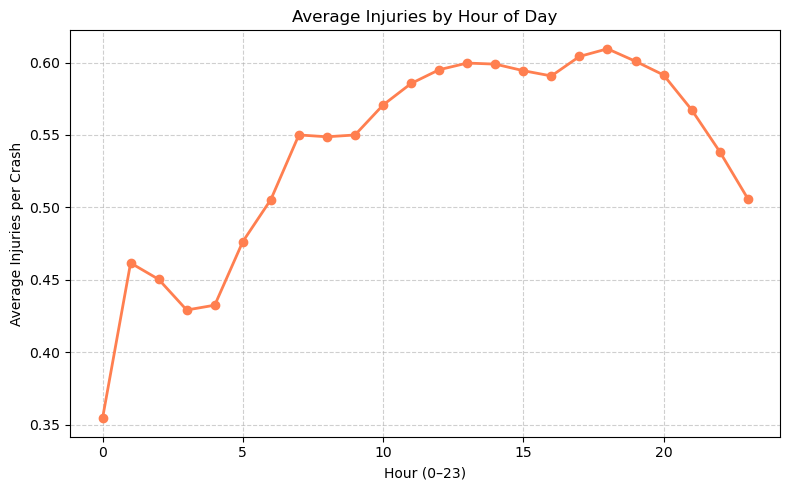

In [66]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
# Compute average injuries per crash for each hour
avg_injuries_hour = (
    crashes_all
    .groupBy("crash_hour")
    .agg(
        (F.sum("number_injured") / F.count("*")).alias("avg_injuries_per_crash")
    )
    .orderBy("crash_hour")
)
# pandas for plotting
pdf = avg_injuries_hour.toPandas()
#  Plot
plt.figure(figsize=(8,5))
plt.plot(pdf["crash_hour"], pdf["avg_injuries_per_crash"], marker='o', color='coral', linewidth=2)
plt.title("Average Injuries by Hour of Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Average Injuries per Crash")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


**Mini-Conclusion:** Average injuries are lowest around midnight and early morning but rise sharply after sunrise, peaking between late morning and early evening. This suggests more severe crashes occur during high-traffic hours.


---

##### 😅 **DID YOU KNOW? — Save Your Sanity Edition**

Crash rates jump during busy hours because overcrowded roads = more chances that something goes wrong.  
And honestly, who wants to deal with that?

Skip the stress.  
**Ride the T 🚇**, read a book, sip a coffee, and let the tracks do the work.  
Stay safe, stay green, and save your sanity!

---


### 4.2 Do highway crashes result in more injuries than non-highway crashes from 2016 to 2025?

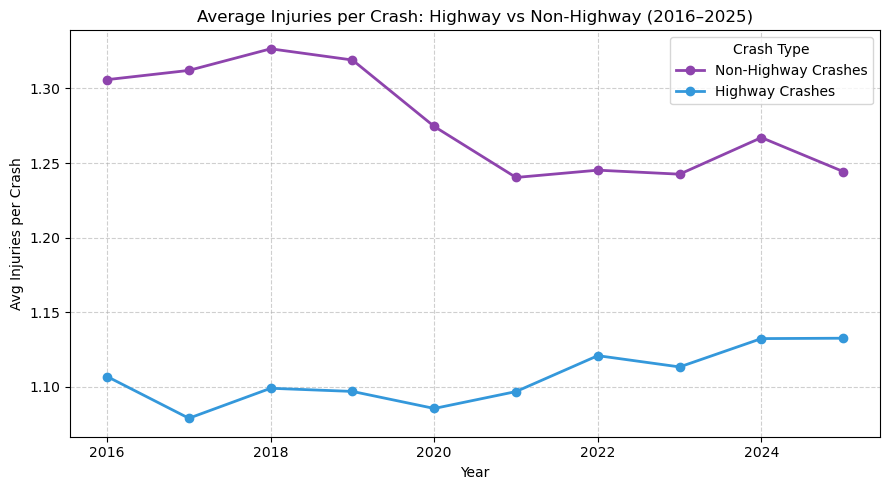

In [67]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd

# 1. Aggregate average injuries per crash by year & highway status
avg_injuries_hw = (
    df_clean
    .groupBy("cr_crash_year", "cr_is_highway_related")
    .agg(
        (F.sum("cr_number_injured") / F.count("*")).alias("avg_injuries_per_crash")
    )
    .orderBy("cr_crash_year", "cr_is_highway_related")
)

# 2. Convert to pandas
pdf = avg_injuries_hw.toPandas()

# 3. Make readable labels for highway vs non-highway
pdf["highway_label"] = pdf["cr_is_highway_related"].map({
    True: "Highway Crashes",
    False: "Non-Highway Crashes",
})

# 4. Plot trends
plt.figure(figsize=(9, 5))
for label, color in zip(
    ["Non-Highway Crashes", "Highway Crashes"],
    ["#8E44AD", "#3498DB"]  # purple, blue
):
    subset = pdf[pdf["highway_label"] == label]
    plt.plot(
        subset["cr_crash_year"],
        subset["avg_injuries_per_crash"],
        marker="o",
        linewidth=2,
        label=label,
        color=color,
    )

plt.title("Average Injuries per Crash: Highway vs Non-Highway (2016–2025)")
plt.xlabel("Year")
plt.ylabel("Avg Injuries per Crash")
plt.legend(title="Crash Type")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

**Mini-Conclusion:** No. Despite the common intuition that higher speeds on highways should result in more severe outcomes, the data from the CCRS and initial exploratory analysis consistently indicates that highway-related crashes have a lower average number of injuries per crash compared to non-highway crashes.


---

##### 😂 MYTH BUSTER: Highway Horror Stories?

We’ve all heard them:  
“The highway is SO dangerous.”  
“City driving is chill.”  
Umm… not according to the data.

**Non-highway crashes actually lead to *more* injuries per crash.**  
Yep — your casual city drive might be more like a boss fight with delivery vans, jaywalkers, and sudden left turns.

Stay safe out there. Myth = defeated. 💥

---


### 4.3 Do people from the younger and older generation lead to higher accidents on an average?

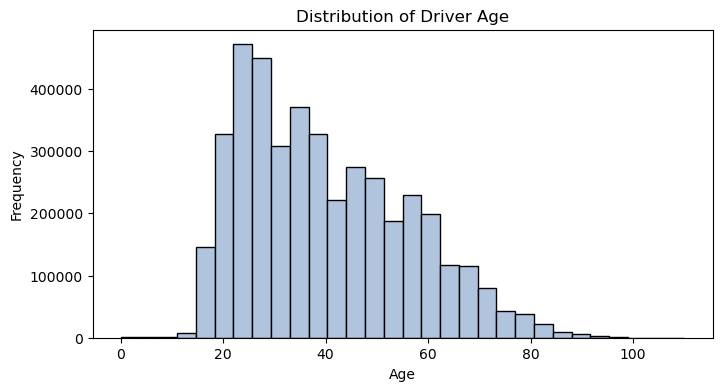

In [68]:
pdf = party_all.select("StatedAge").toPandas()
plt.figure(figsize=(8,4))
plt.hist(pdf["StatedAge"].dropna(), bins=30, color="lightsteelblue", edgecolor="black")
plt.title("Distribution of Driver Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Mini-Conclusion:** As reflected in the graph people in the age groups of 25-27 years old are historically leading to higher accidents as compared to the rest of the age groups.


---

##### 🚗 Story Time: The Quarter-Life Chaos Peak

Turns out there’s a tiny plot twist in the story of road safety…

Right around ages **25 to 27**, drivers hit what we call the *Quarter-Life Chaos Peak*.  
They’re old enough to feel confident, young enough to feel unstoppable, and busy enough to be everywhere at once — work, gym, errands, late-night plans, you name it.

And with more miles, more distractions, and more “I swear I checked my blind spot!” moments…  
this age group ends up topping the crash charts.

So yeah — your mid-20s aren’t just stressful.  
They’re statistically crunchy on the roads too. 😅

---


### 4.4 What are the trends in the various different type of injuries across all the years?

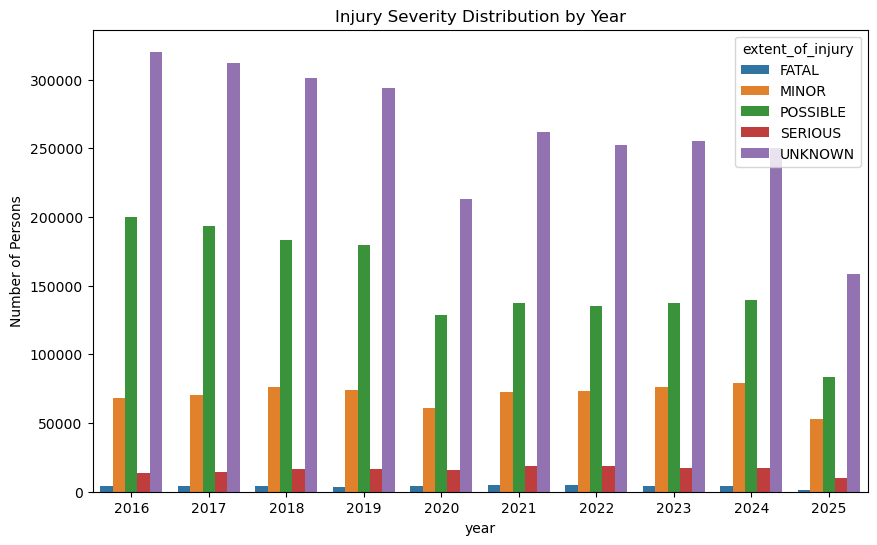

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

severity_year = (
    injury_all.groupBy("year","extent_of_injury")
    .count()
    .orderBy("year","extent_of_injury")
    .toPandas()
)

plt.figure(figsize=(10,6))
sns.barplot(data=severity_year, x="year", y="count", hue="extent_of_injury")
plt.title("Injury Severity Distribution by Year")
plt.ylabel("Number of Persons")
plt.show()

**Mini-Conclusion:** As we can see in the graph, fatalities has decreased with time, Minor injuries have mostly remained constant across years, and the Possible injuries (depending on medical checks) has decreased over the years.

### 4.5 Which age group has the highest serious injuries over the years?

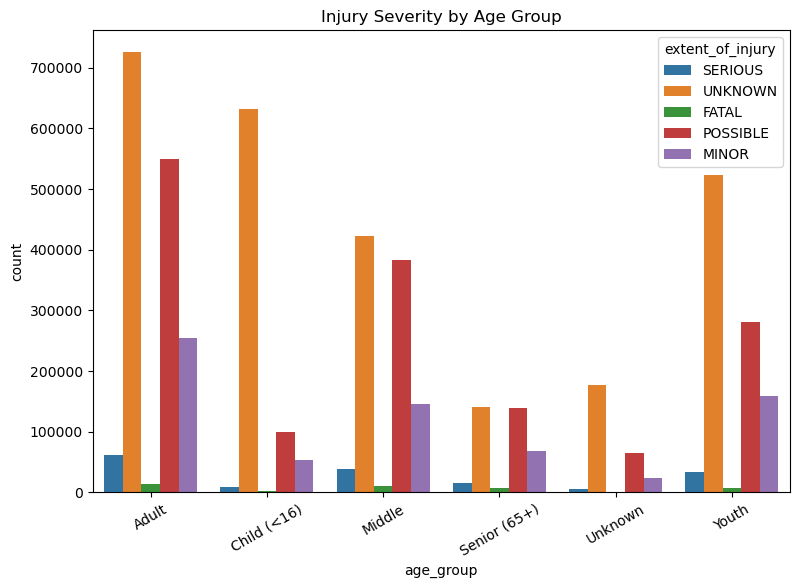

In [70]:
injury_all_fe = injury_all.withColumn("age_group",
        F.when(F.col("StatedAge") < 16, "Child (<16)")
         .when(F.col("StatedAge").between(16, 24), "Youth")
         .when(F.col("StatedAge").between(25, 44), "Adult")
         .when(F.col("StatedAge").between(45, 64), "Middle")
         .when(F.col("StatedAge") >= 65, "Senior (65+)").otherwise("Unknown"))

age_severity = (
    injury_all_fe.groupBy("age_group","extent_of_injury")
    .count()
    .orderBy("age_group")
    .toPandas()
)

plt.figure(figsize=(9,6))
sns.barplot(data=age_severity, x="age_group", y="count", hue="extent_of_injury")
plt.title("Injury Severity by Age Group")
plt.xticks(rotation=30)
plt.show()

**Mini-Conclusion:** As observed from the above graph the adult population is impacted with the highest number of serious injuries. However, it must be taken into consideration that the dataset is also skewed with a larger pool of candidates who are considered as adults.


---

##### 😂 Parents: Do As We Say, Not As We Do

Adults tell everyone to be careful…  
while simultaneously dominating the injury statistics.

Classic adult move. 🚗💫

---


### 4.6 Did the airbags get deployed when vehicles were involved in an acccident?

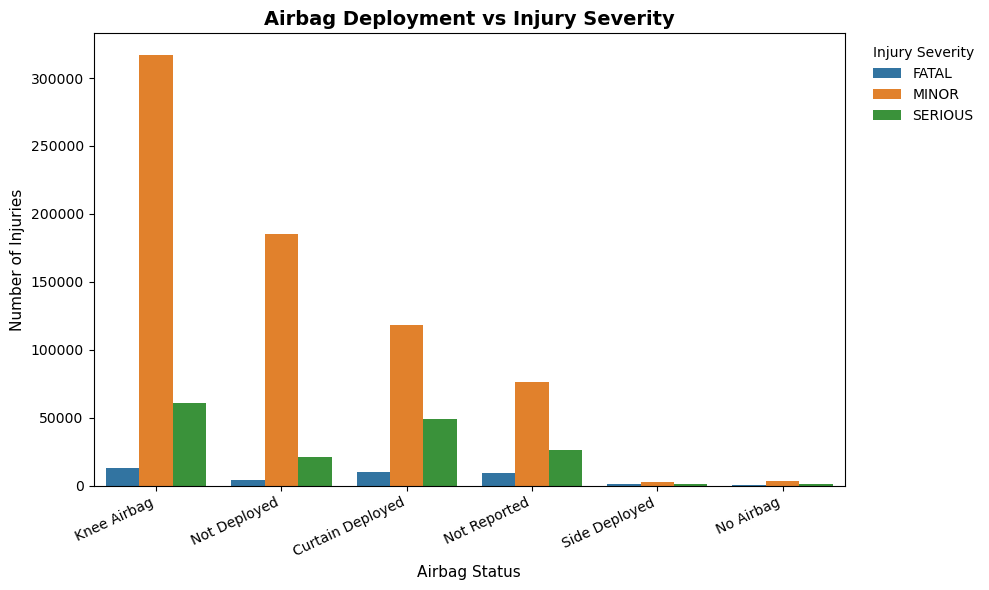

In [71]:
airbag_counts = (
    injury_all
      .select("AirBagCode", "extent_of_injury")
      .withColumn("AirBagCode", F.coalesce(F.col("AirBagCode"), F.lit("X")))
      .groupBy("AirBagCode", "extent_of_injury")
      .count()
      .toPandas()
)
airbag_map = {
    "A": "Front Deployed",
    "B": "Side Deployed",
    "C": "Front + Side",
    "M": "Not Deployed",
    "N": "No Airbag",
    "P": "Curtain Deployed",
    "L": "Knee Airbag",
    "U": "Unknown",
    "X": "Not Reported"
}
airbag_counts["AirBagCode"] = (
    airbag_counts["AirBagCode"].map(airbag_map).fillna(airbag_counts["AirBagCode"])
)
airbag_counts_filtered = airbag_counts[
    ~airbag_counts["extent_of_injury"].isin(["POSSIBLE", "UNKNOWN"])
]
order = (airbag_counts_filtered.groupby("AirBagCode")["count"]
         .sum().sort_values(ascending=False).index.tolist())
plt.figure(figsize=(10, 6))
sns.barplot(
    data=airbag_counts_filtered,
    x="AirBagCode", y="count", hue="extent_of_injury",
    order=order
)
plt.title("Airbag Deployment vs Injury Severity", fontsize=14, fontweight="bold")
plt.xlabel("Airbag Status", fontsize=11)
plt.ylabel("Number of Injuries", fontsize=11)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Injury Severity", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

**Mini-Conclusion:** As observed from the graph, it is estimated that about 250,000 vehicles involved in an accident did not deploy airbags to save lives or decrease injuries. This is the stark reality and a contrast to the safety standards and consumers expections from vehicle manufacturers.


---

##### 😬 Plot Twist: The Airbags Forgot Their Job

Turns out a shocking number of airbags simply didn’t deploy.  
Imagine your safety feature looking at a crash and going:

“Hmm… seems like a *you* problem.” 🤷‍♂️

---


# 5. EDA - After modified dataset

In [72]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

# -------- BASE PATH --------
gcs_path = "gs://dataset_seven/Dataset_year_perfile/clean_dataset.parquet/"

print(f"reading: {gcs_path}  -->  creating: df_clean")

df_clean = (
    spark.read
        .option("header", "true")
        .option("inferSchema", "true")
        .parquet(gcs_path)
)

df_clean.show(5)
df_clean.printSchema()

reading: gs://dataset_seven/Dataset_year_perfile/clean_dataset.parquet/  -->  creating: df_clean
+-----------+-----------+--------------------+-------------+----------+--------+-----------------+-------------------+---------------------+--------------------+--------------+-----------------------+-----------+--------------------+--------------------+-----------------+----------+----------------------+--------------+-------------+--------------+---------------------+--------------+-----------+----------------+------------+-----------------------------------+-----------------+----------------+--------------------------------+---------------------------------+--------------------+-----------------------+------------------------------+------------+-------------------+-------------+-----------+-------------+-------------+--------------+-----------------------+---------------------+---------------+--------------+------------------------+-----------------------------+-------------+------------

In [73]:
df_clean.count()

5024677

In [74]:
df_clean.describe().show()

+-------+------------------+------------------+--------------------+-----------------+----------+--------+---------------------+--------------------+--------------+-----------------------+----------------+--------------------+--------------------+-------------------+------------------+----------------------+------------------+------------------+--------------+-----------------+----------------+-------------------+-----------------------------------+------------------+-------------------+--------------------------------+---------------------------------+--------------------+-----------------------+------------------------------+--------------------+------------------+-----------------+-------------+--------------+-----------------------+---------------------+------------------+------------------------+-----------------------------+------------------+--------------+------------+------------------+------------------+-----------------------+----------------+-------------+
|summary|       c

In [75]:
from pyspark.sql import functions as F

null_counts = df_clean.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_clean.columns])
null_counts.show()

+-----------+-----------+--------------------+-------------+----------+--------+-----------------+-------------------+---------------------+----------------+--------------+-----------------------+-----------+--------------------+--------------------+-----------------+----------+----------------------+--------------+-------------+--------------+---------------------+--------------+-----------+----------------+------------+-----------------------------------+-----------------+----------------+--------------------------------+---------------------------------+-------------------+-----------------------+------------------------------+------------+-----------------+-------------+-----------+-------------+-------------+--------------+-----------------------+---------------------+---------------+--------------+------------------------+-----------------------------+-------------+--------------+------------+------------------+----------------+--------------------+-----------------------+-------

In [76]:
df_clean.show(5, truncate=False)

+-----------+-----------+--------------------+-------------+----------+--------+-----------------+-------------------+---------------------+---------------------+--------------+-----------------------+-----------+--------------------+--------------------+-----------------+----------+----------------------+--------------+-------------+--------------+---------------------+--------------+-----------+----------------+------------+-----------------------------------+-----------------+----------------+--------------------------------+---------------------------------+---------------------+-----------------------+------------------------------+------------+-------------------+-------------+-----------+-------------+-------------+--------------+-----------------------+---------------------+---------------+--------------+------------------------+-----------------------------+-------------+--------------+------------+------------------+----------------+--------------------+----------------------

In [77]:
df_clean.columns

['collisionid',
 'partynumber',
 'inj_InjuredWitPassId',
 'inj_StatedAge',
 'inj_Gender',
 'inj_Race',
 'inj_IsWitnessOnly',
 'inj_IsPassengerOnly',
 'inj_InjuredPersonType',
 'inj_SeatPosition',
 'inj_AirBagCode',
 'inj_SafetyEquipmentCode',
 'inj_Ejected',
 'inj_extent_of_injury',
 'inj_severity_ordinal',
 'inj_severe_binary',
 'cr_city_id',
 'cr_collision_type_code',
 'cr_county_code',
 'cr_crash_year',
 'cr_day_of_week',
 'cr_is_highway_related',
 'cr_is_tow_away',
 'cr_latitude',
 'cr_lighting_code',
 'cr_longitude',
 'cr_motor_vehicle_involved_with_code',
 'cr_number_injured',
 'cr_number_killed',
 'cr_primary_collision_factor_code',
 'cr_primary_collision_party_number',
 'cr_road_condition_1',
 'cr_roadway_surface_code',
 'cr_traffic_control_device_code',
 'cr_weather_1',
 'cr_crash_datetime',
 'cr_crash_hour',
 'pty_PartyId',
 'pty_PartyType',
 'pty_IsAtFault',
 'pty_AirbagCode',
 'pty_SafetyEquipmentCode',
 'pty_DirectionOfTravel',
 'pty_IsHitAndRun',
 'pty_SpeedLimit',
 'pty_

### 5.1 How does injury severity differ across airbag deployment types, and does the presence of deployed airbags reduce the number of severe injuries?

	•	inj_AirBagCode → Type/status of airbag deployment
	•	inj_severity_ordinal → 0–4 scale of injury severity

+--------------+--------------------+-------+
|inj_AirBagCode|inj_severity_ordinal|  count|
+--------------+--------------------+-------+
|             B|                   0|   7161|
|             B|                   1|   4700|
|             B|                   2|   2864|
|             B|                   3|   1166|
|             B|                   4|   1051|
|             L|                   0| 202082|
|             L|                   1| 501794|
|             L|                   2| 316268|
|             L|                   3|  60442|
|             L|                   4|  12967|
|             M|                   0|1310559|
|             M|                   1| 787885|
|             M|                   2| 184920|
|             M|                   3|  21026|
|             M|                   4|   4368|
|             N|                   0|   3593|
|             N|                   1|   4390|
|             N|                   2|   3470|
|             N|                  

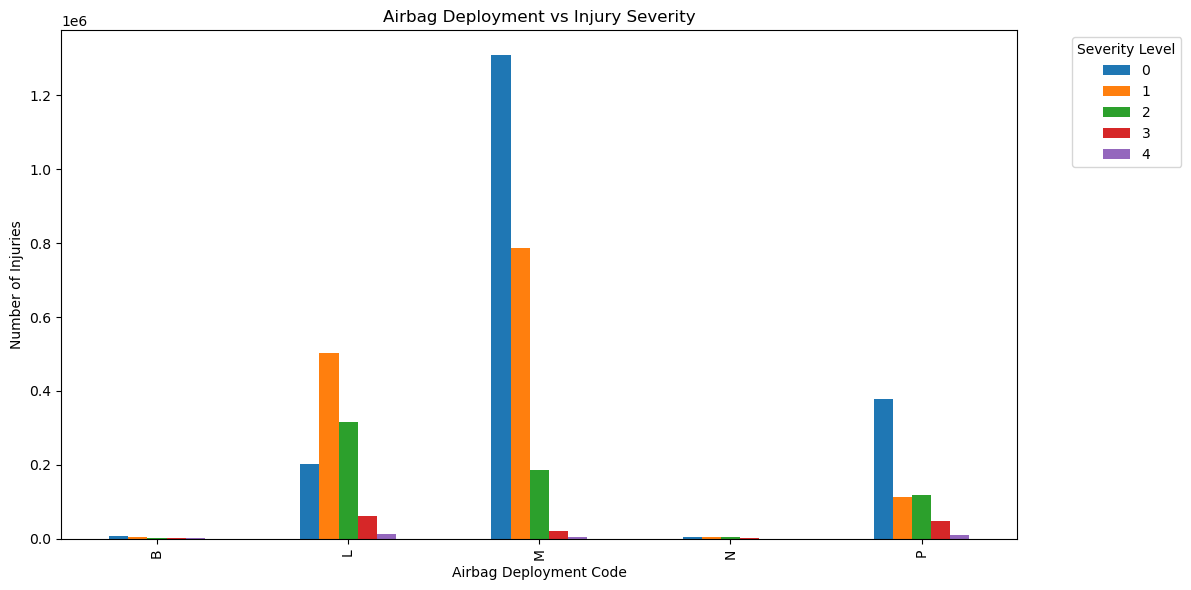

In [78]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd


airbag_col = "inj_AirBagCode"
sev_col = "inj_severity_ordinal"


airbag_vs_sev = (
    df_clean
      .filter(F.col(airbag_col).isNotNull() & F.col(sev_col).isNotNull())
      .groupBy(airbag_col, sev_col)
      .count()
      .orderBy(airbag_col, sev_col)
)

airbag_vs_sev.show()


airbag_pdf = airbag_vs_sev.toPandas()


pivot_df = airbag_pdf.pivot(index=airbag_col, columns=sev_col, values="count").fillna(0)


pivot_df.plot(kind="bar", figsize=(12,6))

plt.xlabel("Airbag Deployment Code")
plt.ylabel("Number of Injuries")
plt.title("Airbag Deployment vs Injury Severity")
plt.legend(title="Severity Level", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

 Airbag Deployment Codes and Their Meanings

| Code | Meaning                          |
|------|----------------------------------|
| B    | Airbag Deployed – Both Front     |
| L    | Airbag Deployed – Left Side      |
| M    | Airbag Deployed – Multiple Bags  |
| N    | No Airbag Deployed               |
| P    | Airbag Deployed – Passenger Side |


**Mini-Conclusion:** The table shows that the M (Multiple Airbags Deployed) category has the highest number of injuries across all severity levels, followed by L (Left Side Airbag Deployed). In contrast, B (Both Front), N (No Airbag), and P (Passenger Side) show much lower injury counts.
This pattern suggests that cases with deployed airbags—especially multiple airbags—are more frequently recorded in injury situations. It also demonstrates vehicle safety technology in action, as airbags are deployed in these cases to protect occupants during more serious impacts.

### 5.2 How does the injury severity differ between individuals who were fully ejected, partially ejected, or not ejected during a crash?

+----------------+--------------------+-------+
|     inj_Ejected|inj_severity_ordinal|  count|
+----------------+--------------------+-------+
|    FULLYEJECTED|                   0|   1033|
|    FULLYEJECTED|                   1|  33223|
|    FULLYEJECTED|                   2|  68165|
|    FULLYEJECTED|                   3|  39131|
|    FULLYEJECTED|                   4|  10306|
|      NOTEJECTED|                   0|1909594|
|      NOTEJECTED|                   1|1396132|
|      NOTEJECTED|                   2| 567106|
|      NOTEJECTED|                   3|  96426|
|      NOTEJECTED|                   4|  18989|
|PARTIALLYEJECTED|                   0|    217|
|PARTIALLYEJECTED|                   1|   5794|
|PARTIALLYEJECTED|                   2|   9164|
|PARTIALLYEJECTED|                   3|   3214|
|PARTIALLYEJECTED|                   4|   1172|
+----------------+--------------------+-------+



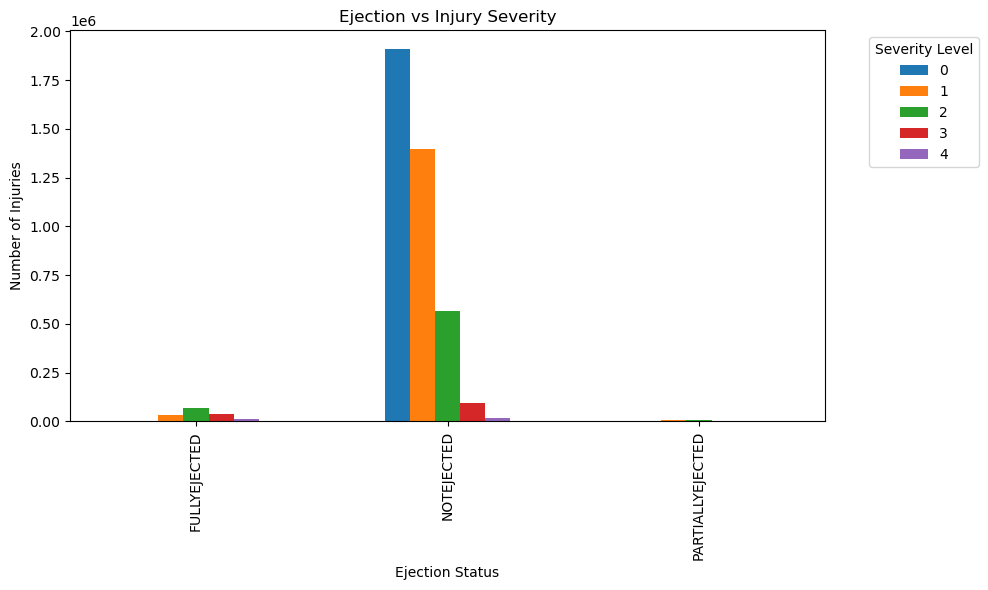

In [79]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd


eject_col = "inj_Ejected"
sev_col = "inj_severity_ordinal"


eject_vs_sev = (
    df_clean
      .filter(F.col(eject_col).isNotNull() & F.col(sev_col).isNotNull())
      .groupBy(eject_col, sev_col)
      .count()
      .orderBy(eject_col, sev_col)
)

eject_vs_sev.show()


eject_pdf = eject_vs_sev.toPandas()


pivot_df = eject_pdf.pivot(index=eject_col, columns=sev_col, values="count").fillna(0)


pivot_df.plot(kind="bar", figsize=(10,6))

plt.xlabel("Ejection Status")
plt.ylabel("Number of Injuries")
plt.title("Ejection vs Injury Severity")
plt.legend(title="Severity Level", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Mini-Conclusion:** The graph shows that the vast majority of injuries occur when individuals are not ejected, and most of these injuries are low severity (levels 0 and 1). However, among those who are fully or partially ejected, the proportion of higher-severity injuries (levels 2, 3, and 4) is noticeably greater relative to their totals. This suggests that ejection from the vehicle significantly increases the likelihood of more severe injuries, even though such events occur far less frequently.

### 5.3 How do different lighting conditions (daylight, dark, dawn/dusk, etc.) influence the number and severity of injuries in vehicle crashes?

+----------------+--------------------+-------+
|cr_lighting_code|inj_severity_ordinal|  count|
+----------------+--------------------+-------+
|               A|                   0|1736498|
|               A|                   1|1037057|
|               A|                   2| 451702|
|               A|                   3|  82773|
|               A|                   4|  14503|
|               B|                   0|  86978|
|               B|                   1|  54976|
|               B|                   2|  25749|
|               B|                   3|   6814|
|               B|                   4|   1742|
|               C|                   0| 499157|
|               C|                   1| 315891|
|               C|                   2| 153238|
|               C|                   3|  43115|
|               C|                   4|  11916|
|               D|                   0| 281309|
|               D|                   1|  99396|
|               D|                   2| 

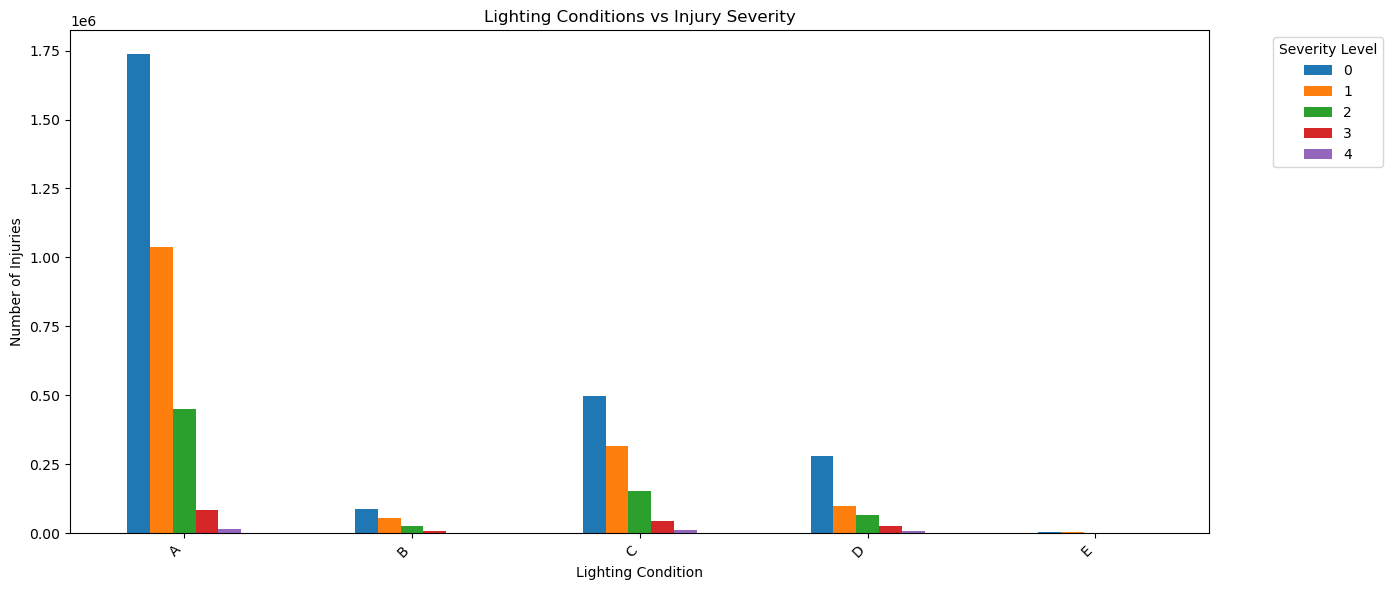

In [80]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd


light_col = "cr_lighting_code"
sev_col = "inj_severity_ordinal"


light_vs_sev = (
    df_clean
      .filter(F.col(light_col).isNotNull() & F.col(sev_col).isNotNull())
      .groupBy(light_col, sev_col)
      .count()
      .orderBy(light_col, sev_col)
)

light_vs_sev.show()


light_pdf = light_vs_sev.toPandas()


pivot_df = light_pdf.pivot(index=light_col, columns=sev_col, values="count").fillna(0)


pivot_df.plot(kind="bar", figsize=(14,6))

plt.xlabel("Lighting Condition")
plt.ylabel("Number of Injuries")
plt.title("Lighting Conditions vs Injury Severity")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Severity Level", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Lighting Condition Codes and Their Meanings:**

| Code | Meaning                       |
|------|-------------------------------|
| A    | Daylight                      |
| B    | Dark – Not Lighted            |
| C    | Dark – Lighted                |
| D    | Dawn or Dusk                  |
| E    | Unknown / Other Lighting      |


**Mini-Conclusion:** The graph shows that daylight conditions account for the highest number of injuries across all severity levels, simply because most driving occurs during the day. However, when looking at lower-frequency conditions such as dark or dawn/dusk, the proportion of moderate to severe injuries (levels 2–4) is noticeably higher relative to their totals. This suggests that reduced visibility contributes to more severe injuries, even though the overall number of crashes in those lighting conditions is much lower.


---

##### ⚡ MYTH vs FACT

**Myth:** Daylight driving is the safest.  
**Fact:** Daylight only *looks* safe because that’s when everyone is driving.  
Nighttime and dawn/dusk have a way higher chance of severe injuries — fewer crashes, but more painful ones.

Visibility matters. A lot.

---


### 5.4 How does injury severity vary across different age groups?

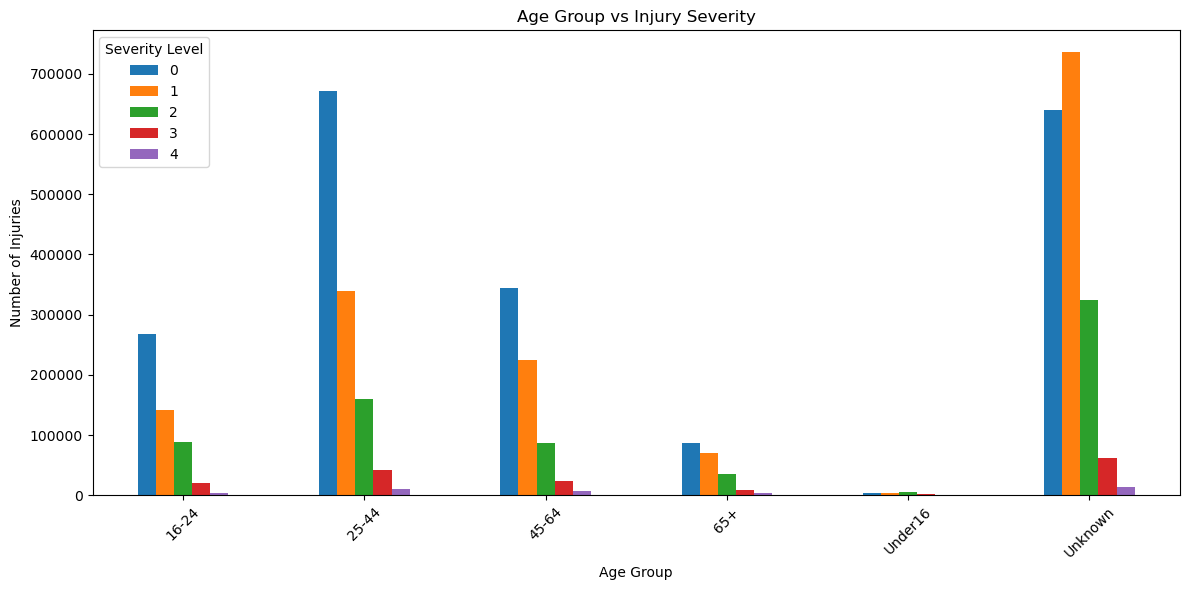

In [81]:
age_col = "pty_age_group"
sev_col = "inj_severity_ordinal"

age_sev = (
    df_clean
    .filter(F.col(age_col).isNotNull() & F.col(sev_col).isNotNull())
    .groupBy(age_col, sev_col)
    .count()
)

pdf = age_sev.toPandas()
pivot = pdf.pivot(index=age_col, columns=sev_col, values="count").fillna(0)

pivot.plot(kind="bar", figsize=(12,6))
plt.title("Age Group vs Injury Severity")
plt.xlabel("Age Group")
plt.ylabel("Number of Injuries")
plt.legend(title="Severity Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Mini-Conclusion:** Most injuries occur among adults aged 25–44, followed by 45–64. However, the severity distribution remains similar across age groups, with mild injuries being the most common. Younger (16–24) and older (65+) groups show slightly higher proportions of moderate/severe injuries. The Unknown age group shows the highest number of recorded injuries in the dataset, with the majority classified as no injuries reported to minor injuries.


---

##### 🎬 Story Time: The Unexpected Plot Twist

You might expect the youngest or oldest drivers to dominate the injury charts.  
But no — the plot twist is that **25–44-year-olds** actually lead by a huge margin.

Why?  
Because this is the “running-on-coffee-and-deadlines” phase of life.  
They're commuting, dropping kids off, rushing to meetings, squeezing errands between errands.  
With so much road time, injuries naturally spike.

The teens and seniors?  
They appear less, but when they do, the injuries can be more serious.

The biggest twist?  
The “Unknown” age group casually shows up with thousands of injuries  
— like a mysterious side character who never reveals their backstory.

---


### 5.5 Which numeric variables show the strongest relationships with injury severity?

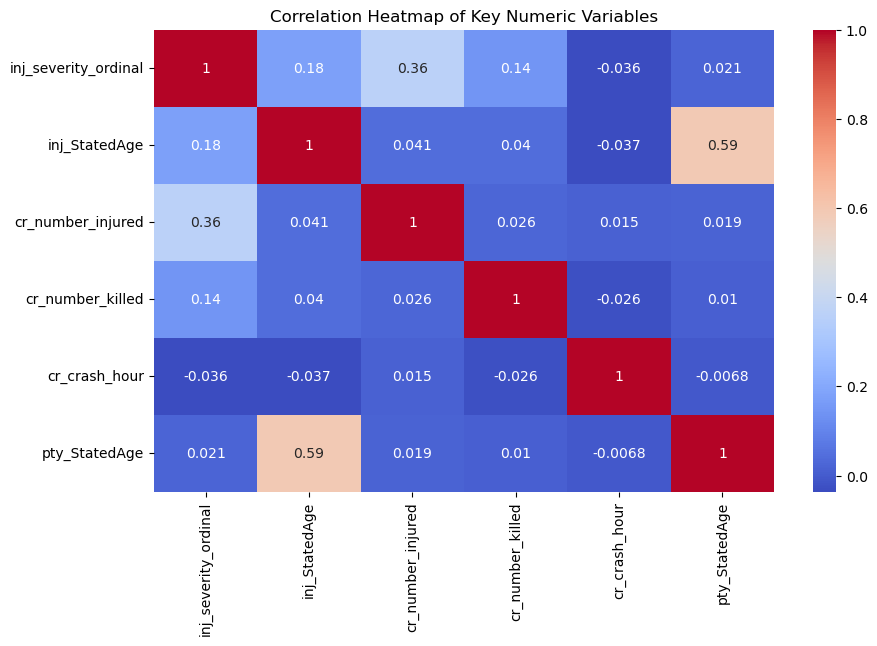

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Select numeric columns for correlation
num_cols = [
    "inj_severity_ordinal",
    "inj_StatedAge",
    "cr_number_injured",
    "cr_number_killed",
    "cr_crash_hour",
    "pty_StatedAge"
]

pdf = df_clean.select(num_cols).toPandas()

plt.figure(figsize=(10,6))
sns.heatmap(pdf.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Key Numeric Variables")
plt.show()

**Mini-Conclusion:** The most significant finding is the moderately strong positive correlation (0.59) between the stated age of the injured person (inj_StatedAge) and the stated age of the party involved (pty_StatedAge). This suggests that accidents frequently involve individuals from similar age brackets—either traveling together or encountering others of the same generation—driving the relationship between these two variables. For predicting injury severity (inj_severity_ordinal), the strongest indicator within this matrix is the number of injured people (cr_number_injured), with a weak positive correlation of 0.36, followed by the inj_StatedAge (0.18) and cr_number_killed (0.14). Critically, all other observed correlations, including the highest negative ones (-0.037 between inj_StatedAge and cr_crash_hour), are extremely weak (close to zero). In conclusion, while the age relationship is noticeable, the dataset's overall relationships for crash outcomes like severity are generally weak, indicating that variables outside this matrix likely have a much greater influence on crash dynamics.


### 5.6 At what time of the day do crashes occur most frequently?

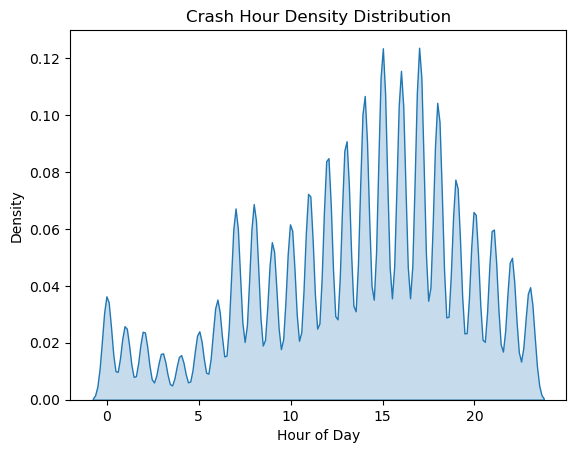

In [83]:
sns.kdeplot(
    data=df_clean.select("cr_crash_hour").toPandas(),
    x="cr_crash_hour",
    fill=True
)
plt.title("Crash Hour Density Distribution")
plt.xlabel("Hour of Day")
plt.show()

**Mini-Conclusion:** Crashes occur most often during the afternoon and early evening hours (around 14:00–18:00). Crash frequency rises steadily from morning to late afternoon before declining at night, reflecting peak traffic times.

### 5.7 Does average injury severity vary throughout the week?

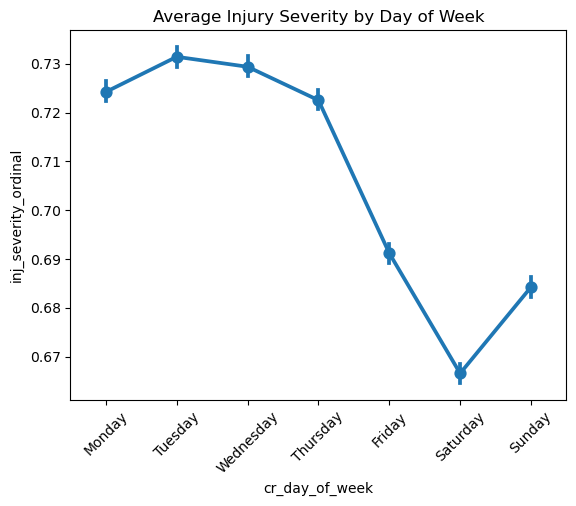

In [84]:
pdf = df_clean.select("cr_day_of_week", "inj_severity_ordinal").toPandas()

pdf["cr_day_of_week"] = pdf["cr_day_of_week"].str.title()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]
import pandas as pd
pdf["cr_day_of_week"] = pd.Categorical(
    pdf["cr_day_of_week"],
    categories=day_order,
    ordered=True
)
sns.pointplot(
    data=pdf,
    x="cr_day_of_week",
    y="inj_severity_ordinal",
    estimator="mean",
    order=day_order   
)
plt.title("Average Injury Severity by Day of Week")
plt.xticks(rotation=45)
plt.show()


**Mini-Conclusion:** Average severity is lowest on Saturday and highest on Tuesday, with weekdays slightly more severe overall. This may reflect differences in traffic patterns, with weekday commuter traffic associated with more serious crashes.


---

##### 😅 Beware the Tuesday Curse

Monday gets all the bad PR, but the REAL menace on the road is…  
**Tuesday.**

Severity peaks. Drivers rush harder. Brains still booting from the weekend.  
Tuesday traffic is basically everyone saying:  
“I’m absolutely fine 🙂”  
while driving like they’re absolutely *not*.

Meanwhile, **Saturday** is vibing, calm, and statistically the safest.

Take the **T** during the workweek and skip the Tuesday Curse entirely. 🚇✨

---


### 5.8 How has the number of crashes changed over recent years?

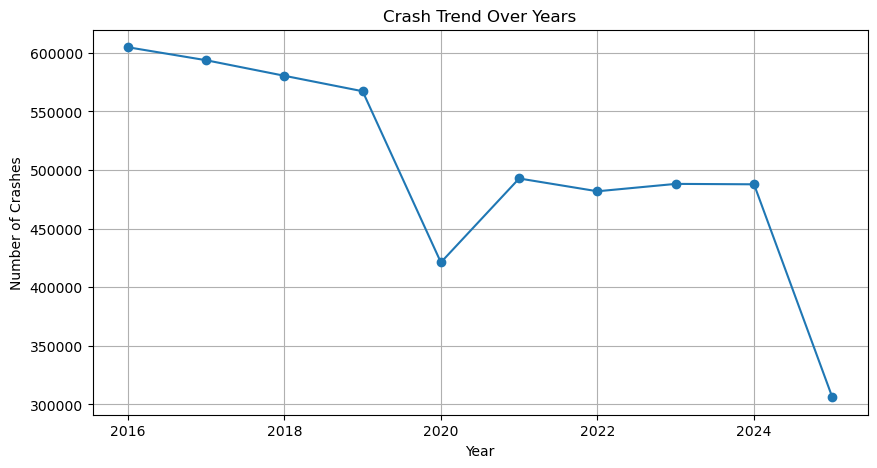

In [85]:
year_col = "cr_crash_year"

year_counts = (
    df_clean.groupBy(year_col)
    .count()
    .orderBy(year_col)
    .toPandas()
)

plt.figure(figsize=(10,5))
plt.plot(year_counts[year_col], year_counts["count"], marker="o")
plt.title("Crash Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
plt.grid(True)
plt.show()

**Mini-Conclusion:** Crashes steadily declined from 2016 to 2019, dropped sharply in 2020 (likely due to COVID-19 reduced travel), and then partially rebounded through 2024. The overall long-term trend shows a decline. 


---

##### 😂 Funny Bones Moment

See that huge dip in 2020?  
Yeah… COVID didn’t just cancel concerts, vacations, and haircuts —  
it also canceled **crashes**.

Turns out when everyone stayed home making sourdough, the roads finally got a break too.  
Who knew the safest driving tip was simply: “Don’t go anywhere for a year.” 😅

---


### 5.9 How do speed limits relate to injury severity?

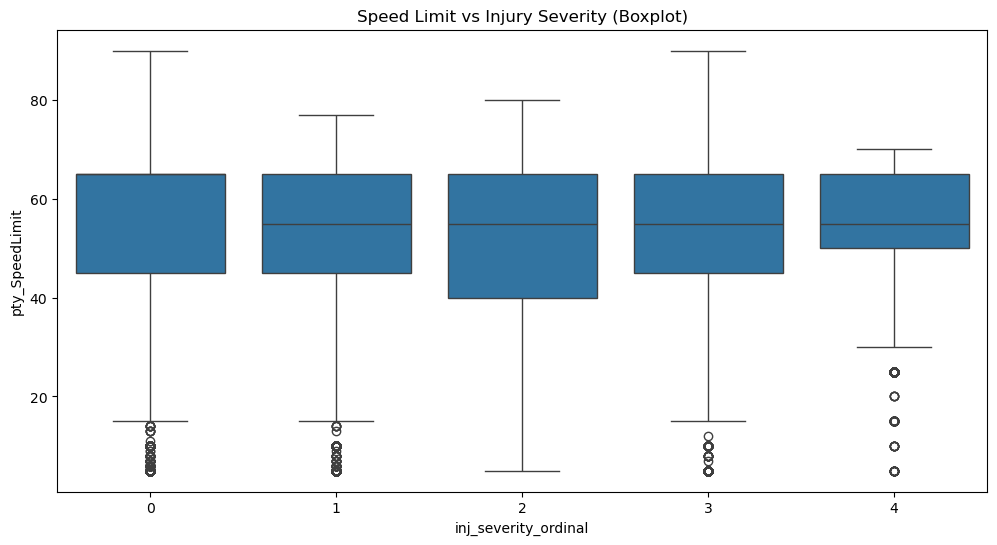

In [86]:
import seaborn as sns
speed_col = "pty_SpeedLimit"

pdf = df_clean.select(speed_col, "inj_severity_ordinal") \
              .dropna() \
              .toPandas()

plt.figure(figsize=(12,6))
sns.boxplot(
    data=pdf,
    x="inj_severity_ordinal",
    y=speed_col
)
plt.title("Speed Limit vs Injury Severity (Boxplot)")
plt.show()

**Mini-Conclusion:** Higher severity injuries are associated with higher median speed limits, but the overlap is large, indicating that while speed contributes to injury severity, it is not the sole determining factor.

# 6. Machine Learning Model

### 6.1 A Race Against the Golden Hour — Why This Model Matters

A crash happens. A 911 call comes in.  
Before responders even start their engines, the clock begins ticking — the *Golden Hour*.  
Those first 60 minutes can determine whether a critically injured person survives.

But dispatchers face chaos: stressed callers, unclear descriptions, missing details, and no real sense of how severe the crash actually is.  
Was it a minor bump… or a life-threatening impact?  
Should they send standard units… or specialized trauma response?

Right now, that decision is made with **very limited information**.

Our model changes that timeline:

1. **Minute 0 — The Call Arrives**  
   Only “at-the-call” features are available: crash hour, location, weather, lighting, road surface, party type.

2. **Minute 0–1 — ML Model Activates**  
   The model instantly evaluates these context clues and produces a **probability of severe injury**.

3. **Minute 1–2 — Dispatcher Insight**  
   Instead of guessing, dispatchers receive a real-time risk signal:  
   *“This crash has elevated severe-injury likelihood.”*

4. **Minute 2–5 — Faster, Smarter Deployment**  
   Calls that need urgent review rise to the top of the queue, improving triage even when phone descriptions are unclear.

This system doesn’t replace dispatchers — it **supports them** in the most stressful, information-poor moment of the entire emergency response process.



### 6.2 Loading Parquet Files from Google Cloud Storage (GCS) Using PySpark


**Read Parquet Dataset:**


In [87]:
# Imports and Spark session

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, Imputer
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

spark = SparkSession.builder \
    .appName("Load Parquet from GCS") \
    .getOrCreate()

df = spark.read.parquet("gs://dataset_seven/Dataset_year_perfile/clean_dataset.parquet")
df.printSchema()


25/12/08 04:36:46 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


root
 |-- collisionid: long (nullable = true)
 |-- partynumber: integer (nullable = true)
 |-- inj_InjuredWitPassId: long (nullable = true)
 |-- inj_StatedAge: integer (nullable = true)
 |-- inj_Gender: string (nullable = true)
 |-- inj_Race: string (nullable = true)
 |-- inj_IsWitnessOnly: boolean (nullable = true)
 |-- inj_IsPassengerOnly: boolean (nullable = true)
 |-- inj_InjuredPersonType: string (nullable = true)
 |-- inj_SeatPosition: string (nullable = true)
 |-- inj_AirBagCode: string (nullable = true)
 |-- inj_SafetyEquipmentCode: string (nullable = true)
 |-- inj_Ejected: string (nullable = true)
 |-- inj_extent_of_injury: string (nullable = true)
 |-- inj_severity_ordinal: integer (nullable = true)
 |-- inj_severe_binary: integer (nullable = true)
 |-- cr_city_id: integer (nullable = true)
 |-- cr_collision_type_code: string (nullable = true)
 |-- cr_county_code: integer (nullable = true)
 |-- cr_crash_year: integer (nullable = true)
 |-- cr_day_of_week: string (nullable = 

In [88]:
df.limit(5).toPandas()

,collisionid,partynumber,inj_InjuredWitPassId,inj_StatedAge,inj_Gender,inj_Race,inj_IsWitnessOnly,inj_IsPassengerOnly,inj_InjuredPersonType,inj_SeatPosition,...,pty_StatedAge,pty_GenderCode,pty_RaceCode,pty_Vehicle1TypeId,pty_Vehicle1Year,pty_V1IsVehicleTowed,pty_cell_phone_use_type,pty_hazardous_material,pty_vehicle_age,pty_age_group
0,87401,2,116327,12,M,None,False,True,None,PASSENGERMIDDLERIGHT,...,42,M,H,22,2004,None,NOT_IN_USE,False,12,25-44
1,87443,1,116393,24,M,B,False,False,DRIVER,DRIVER,...,24,M,B,1,2006,None,NOT_IN_USE,False,10,16-24
2,87533,1,116545,37,M,None,False,True,None,PASSENGERMIDDLEMIDDLE,...,46,M,A,1,2007,None,NOT_IN_USE,False,9,45-64
3,87573,2,116603,38,F,None,False,False,PASSENGER,PASSENGERMIDDLERIGHT,...,33,M,H,1,2010,None,NOT_IN_USE,False,6,25-44
4,87573,2,116605,25,M,None,False,True,None,PASSENGERFRONTRIGHT,...,33,M,H,1,2010,None,NOT_IN_USE,False,6,25-44


In [89]:
df.count()

5024677

In [90]:
len(df.columns)

57

### 6.3 Hypothesis: Can Context Alone Predict Crash Severity at Dispatch Time?

Before building machine learning models, we first examine a fundamental scientific question:

---

**H₀ — Null Hypothesis**

Environmental and contextual features available at dispatch time  
(e.g., crash hour, weather, lighting, road surface, party type)  
**have *no* relationship with injury severity.**  
Under this hypothesis, severity appears random with respect to dispatch-time information.

---

**H₁ — Alternative Hypothesis**

Dispatch-time features **do** have a measurable association with injury severity  
and can help **identify high-risk crashes early**, even before any medical assessment or on-scene details are available.

---

This hypothesis test guides whether a triage-assist model is even feasible using only the limited information dispatchers receive at the moment a 911 call arrives.


In [91]:
from pyspark.sql import functions as F

# Create a numeric label column from the binary injury flag
# inj_severe_binary is probably 0/1 
df = df.withColumn(
    "label",
    F.col("inj_severe_binary").cast("double")
)

# drop rows where label is null
df = df.filter(F.col("label").isNotNull())

In [92]:
# Create df_model from the cleaned final dataset

required_cols = [
    "cr_crash_hour",
    "cr_day_of_week",
    "cr_weather_1",
    "cr_roadway_surface_code",
    "cr_lighting_code",
    "pty_PartyType",
    "label"
]

# Keep only rows where label exists
df_model = df.select(required_cols).na.drop(subset=["label"])

print("df_model created with rows:", df_model.count())
df_model.show(5)

df_model created with rows: 5024677
+-------------+--------------+------------+-----------------------+----------------+-------------+-----+
|cr_crash_hour|cr_day_of_week|cr_weather_1|cr_roadway_surface_code|cr_lighting_code|pty_PartyType|label|
+-------------+--------------+------------+-----------------------+----------------+-------------+-----+
|           13|      SATURDAY|       CLEAR|                      A|               A|       DRIVER|  0.0|
|            1|        FRIDAY|       CLEAR|                      A|               C|       DRIVER|  0.0|
|           17|      SATURDAY|       CLEAR|                      A|               C|       DRIVER|  0.0|
|           12|      SATURDAY|       CLEAR|                      A|               A|       DRIVER|  0.0|
|           12|      SATURDAY|       CLEAR|                      A|               A|       DRIVER|  0.0|
+-------------+--------------+------------+-----------------------+----------------+-------------+-----+
only showing top 5 

In [93]:
# Build a clean dataset for statistics
import pyspark.sql.functions as F


stats_cols = [
    "cr_crash_hour",           # numeric
    "cr_day_of_week",          # categorical
    "cr_weather_1",            # categorical
    "cr_roadway_surface_code", # categorical
    "cr_lighting_code",        # categorical
    "pty_PartyType",           # categorical
    "label"                    # target
]

df_stats = df_model.select(stats_cols)

# Drop rows with nulls 
df_stats_clean = df_stats.na.drop(subset=stats_cols)

print("Rows in df_model       :", df_model.count())
print("Rows in df_stats_clean :", df_stats_clean.count())

# Spearman correlation for crash hour
sample_pdf = (
    df_stats_clean
    .select("cr_crash_hour", "label")
    .sample(withReplacement=False, fraction=0.05)  
    .toPandas()
)

spearman_corr = sample_pdf["cr_crash_hour"].corr(sample_pdf["label"], method="spearman")

print("\nSpearman correlation between cr_crash_hour and label:")
print(f"Spearman rho = {spearman_corr:.4f}")


Rows in df_model       : 5024677


Rows in df_stats_clean : 4391114



Spearman correlation between cr_crash_hour and label:
Spearman rho = -0.0095


**Interpretation:** The Spearman correlation between crash hour and injury severity is extremely close to zero (ρ = –0.0062), indicating no meaningful monotonic relationship between the time of day and the likelihood of a severe injury. This confirms that crash hour alone is not predictive and only gains value when combined with other contextual features in the model.

In [94]:
# Chi-square + Cramér's V for categorical features
import numpy as np
import pandas as pd

categorical_cols = [
    "cr_day_of_week",
    "cr_weather_1",
    "cr_roadway_surface_code",
    "cr_lighting_code",
    "pty_PartyType"
]

def chi2_cramers_v(df, cat_col, label_col="label"):
    """
    Compute Chi-square statistic and Cramér's V for
    a categorical feature vs. the label.
    Uses aggregated counts only (safe for big data).
    """
    # Contingency table: cat_col x label
    ct = df.groupBy(cat_col, label_col).count().toPandas()

    # Pivot to matrix form
    table = ct.pivot(index=cat_col, columns=label_col, values="count").fillna(0)
    observed = table.values

    n = observed.sum()
    row_sums = observed.sum(axis=1).reshape(-1, 1)
    col_sums = observed.sum(axis=0).reshape(1, -1)
    expected = row_sums * col_sums / n

    # Chi-square statistic
    chi2 = ((observed - expected) ** 2 / expected).sum()

    # Cramér's V
    r, c = observed.shape
    phi2 = chi2 / n
    k = min(r - 1, c - 1)
    if k <= 0:
        cramers_v = 0.0
    else:
        cramers_v = float(np.sqrt(phi2 / k))

    dof = (r - 1) * (c - 1)
    return float(chi2), int(dof), cramers_v

results = []

for col_name in categorical_cols:
    chi2, dof, v = chi2_cramers_v(df_stats_clean, col_name, label_col="label")
    results.append({
        "feature": col_name,
        "chi2_stat": chi2,
        "dof": dof,
        "cramers_v": v
    })

results_df = pd.DataFrame(results).sort_values("cramers_v", ascending=False)
results_df


,feature,chi2_stat,dof,cramers_v
4,pty_PartyType,152437.699307,5,0.186320
3,cr_lighting_code,36473.458025,4,0.091138
0,cr_day_of_week,2443.451375,6,0.023589
1,cr_weather_1,1163.473302,167,0.016278
2,cr_roadway_surface_code,96.500282,3,0.004688


**Interpretation of Statistical Tests**

The statistical analysis shows that most **individual** dispatch-time features have **very weak standalone associations** with injury severity.

---

**1. Crash Hour — Spearman Correlation**

- **Spearman ρ ≈ –0.006**  
- This value is extremely close to zero → **crash hour has no meaningful relationship** with whether a crash becomes severe.

---

**2. Categorical Features — Chi-Square & Cramér’s V**

**Effect Sizes**

- **Party Type — Cramér’s V ≈ 0.186**  
  - Weak association, but **strongest among all features**.  
  - Vulnerable road users (motorcyclists, pedestrians, cyclists) show higher severity.

- **Lighting Conditions — Cramér’s V ≈ 0.091**  
  - Very weak association, but severity increases slightly in darker environments.

- **Day of Week — Cramér’s V ≈ 0.024**  
- **Weather — Cramér’s V ≈ 0.016**  
- **Road Surface — Cramér’s V ≈ 0.005**  
  - **Negligible associations**.

---

**Overall Conclusion**

Individually, these contextual features are **not strong predictors** of injury severity.  
However, when **combined** inside a machine learning model, they may still provide value by contributing:

- interaction effects  
- nonlinear relationships  
- subtle patterns not detectable through simple statistical tests  

This is why the ML model can perform meaningfully even when individual correlations appear weak.


### 6.4 The "Golden Hour" Algorithm – Predictive Dispatch for EMS

---

##### 6.4.a. The Business Problem (The “Why”)

In emergency medical response, the **Golden Hour** represents the critical 60-minute window after a serious crash where rapid intervention dramatically increases survival chances.

But dispatchers face a major challenge:

**The Problem:**
When a 911 call comes in, dispatchers often have:

- noisy or incomplete information  
- stressed callers  
- unclear or conflicting descriptions  
- **no immediate knowledge of injury severity**

This uncertainty creates serious risks:

- **Under-response** → delayed trauma care  
- **Over-response** → unnecessary deployment of specialized units  

**The Objective:**
Build a **triage-assist model** that predicts the likelihood of *severe injury* using **only information available at the time of the call**, helping dispatchers prioritize which calls need faster review.



---

##### 6.4.b. The Data Strategy (The “What”)

We analyzed **5 million+ California crash records** from **2016–2025**.

**Leakage Prevention — “Dispatch Timeline Rule”**

To mimic real dispatcher conditions, we **strictly retained only features known *before* dispatch decisions**.

**Included (safe, at-the-call context features)**  
- **Time:** crash hour, day of week  
- **Environment:** weather, lighting, road surface  
- **Geography:** latitude / longitude  
- **Caller-provided info:** party type  

**Excluded (forbidden future or post-crash info)**  
- Number of fatalities or injuries  
- Tow-away status  
- Primary collision factor  
- Damage severity codes  
- Any post-collision outcome  

This prevents information leakage and ensures the model reflects **real-world dispatcher information flow**.

---


In [95]:
# Setup and Data Cleaning

from pyspark.sql import functions as F
from pyspark.ml.feature import Imputer

# Define the "Golden Hour" Target
# Predict 'inj_severe_binary' (1 = Severe/Fatal, 0 = Minor/Pain)
# If this column doesn't exist in your filtered dataset, create it from 'inj_severity_ordinal'
target_col = "inj_severe_binary"

# Define "Safe" Features (Known at dispatch time)
# Drop "Tow Away", "Killed count", "Fault"
weather_col = "cr_weather_1"
surface_col = "cr_roadway_surface_code"
lighting_col = "cr_lighting_code"
day_col = "cr_day_of_week"
time_col = "cr_crash_hour"
lat_col = "cr_latitude"
long_col = "cr_longitude"

# columns to keep
required_cols = [target_col, time_col, lat_col, long_col, 
                 weather_col, surface_col, lighting_col, day_col]

# Filter Data
# Drop rows where the target is missing 
df_model = df.select(required_cols).filter(F.col(target_col).isNotNull())

# Cast target to Double 
df_model = df_model.withColumn("label", F.col(target_col).cast("double"))

# Impute Missing Location Data
# If Lat/Long is null, fill with mean
imputer = Imputer(
    inputCols=[lat_col, long_col], 
    outputCols=["lat_imp", "long_imp"]
).setStrategy("mean")

print(f"Modeling Dataset Count: {df_model.count()}")
df_model.printSchema()

Modeling Dataset Count: 5024677
root
 |-- inj_severe_binary: integer (nullable = true)
 |-- cr_crash_hour: integer (nullable = true)
 |-- cr_latitude: double (nullable = true)
 |-- cr_longitude: double (nullable = true)
 |-- cr_weather_1: string (nullable = true)
 |-- cr_roadway_surface_code: string (nullable = true)
 |-- cr_lighting_code: string (nullable = true)
 |-- cr_day_of_week: string (nullable = true)
 |-- label: double (nullable = true)



In [96]:
from pyspark.sql import functions as F

print("Total rows in df_model:", df_model.count())

# Class distribution
class_counts = (
    df_model.groupBy("label")
            .count()
            .orderBy("label")
)
class_counts.show()

total = df_model.count()
class_stats = class_counts.withColumn(
    "pct",
    F.col("count") / F.lit(total)
)
class_stats.show()

# Baseline: predict majority class
majority_row = class_stats.orderBy(F.desc("pct")).first()
majority_label = majority_row["label"]
majority_pct = majority_row["pct"]

print(f"\nMajority class label: {majority_label}")
print(f"Baseline accuracy if we always predict {majority_label}: {majority_pct:.3f}")
print("Our model needs to beat this, not just 0.5 random chance.")

Total rows in df_model: 5024677


+-----+-------+
|label|  count|
+-----+-------+
|  0.0|4827934|
|  1.0| 196743|
+-----+-------+



+-----+-------+-------------------+
|label|  count|                pct|
+-----+-------+-------------------+
|  0.0|4827934| 0.9608446473275795|
|  1.0| 196743|0.03915535267242053|
+-----+-------+-------------------+




Majority class label: 0.0
Baseline accuracy if we always predict 0.0: 0.961
Our model needs to beat this, not just 0.5 random chance.


**Class Balance and Baseline Performance:**

The dataset contains a total of 5,024,677 crash records. Of these, approximately 96% are non-severe (label = 0) and only 4% are severe (label = 1), confirming that injury severity is highly imbalanced. Because of this imbalance, a naïve model that simply predicts “non-severe” for every case would already achieve about 96.1% accuracy. This highlights why accuracy alone is not a meaningful metric in this context: a model can appear highly accurate while completely failing to identify severe crashes. Instead, evaluation must prioritize recall, precision-recall behavior, and PR-AUC to ensure the model actually detects the small but critical proportion of severe injuries.

In [97]:
# Re-run the filtering 
required_cols = [target_col, time_col, lat_col, long_col, 
                 weather_col, surface_col, lighting_col, day_col, "pty_PartyType"]

df_model = df.select(required_cols).filter(F.col(target_col).isNotNull())
df_model = df_model.withColumn("label", F.col(target_col).cast("double"))

# run randomSplit
train_df, test_df = df_model.randomSplit([0.8, 0.2], seed=42)

print(f"Train count: {train_df.count()}")
print(f"Test count: {test_df.count()}")

Train count: 4019347


Test count: 1005330


**Next Step:** Checking the amount of nulls

In [98]:
import pyspark.sql.functions as F

cols_to_check = [
    "cr_crash_hour", "cr_day_of_week", "cr_weather_1", 
    "cr_roadway_surface_code", "cr_lighting_code",
    "cr_latitude", "cr_longitude", "pty_PartyType"
]

df_model.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c + "_nulls")
    for c in cols_to_check
]).show()


+-------------------+--------------------+------------------+-----------------------------+----------------------+-----------------+------------------+-------------------+
|cr_crash_hour_nulls|cr_day_of_week_nulls|cr_weather_1_nulls|cr_roadway_surface_code_nulls|cr_lighting_code_nulls|cr_latitude_nulls|cr_longitude_nulls|pty_PartyType_nulls|
+-------------------+--------------------+------------------+-----------------------------+----------------------+-----------------+------------------+-------------------+
|                  0|                   0|             13752|                        19150|                  9910|          1373362|           1373362|             597938|
+-------------------+--------------------+------------------+-----------------------------+----------------------+-----------------+------------------+-------------------+



In [99]:
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
import pyspark.sql.functions as F

candidate_cols = [
    "cr_crash_hour", 
    "cr_day_of_week", 
    "cr_weather_1", 
    "cr_roadway_surface_code", 
    "cr_lighting_code",
    "pty_PartyType"
]

# Separate categorical and numeric columns
categorical_cols = [
    "cr_day_of_week",
    "cr_weather_1",
    "cr_roadway_surface_code",
    "cr_lighting_code",
    "pty_PartyType"
]

numeric_cols = [
    "cr_crash_hour"
]

stages = []
input_cols = []

#StringIndexers for categorical variables
for c in categorical_cols:
    indexer = StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    stages.append(indexer)
    input_cols.append(f"{c}_idx")

#Numeric columns go in directly
input_cols.extend(numeric_cols)

# Vector Assembler 
assembler = VectorAssembler(
    inputCols=input_cols,
    outputCol="features",
    handleInvalid="skip"    
)
stages.append(assembler)

# Random Forest Classifier
rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=100,
    maxDepth=5,
    maxBins=512,  
    seed=42
)
stages.append(rf)

# Build the pipeline
selector_pipeline = Pipeline(stages=stages)

cols_needed = candidate_cols + ["label"]
df_model_clean = df_model.na.drop(subset=cols_needed)

print("Rows before cleaning:", df_model.count())
print("Rows after cleaning :", df_model_clean.count())

#Fit the model
selector_model = selector_pipeline.fit(df_model_clean)

#Extract and Print Feature Importances
rf_model = selector_model.stages[-1]
importances = rf_model.featureImportances

print("\n--- Feature Importance Scores ---")
feature_data = list(zip(input_cols, importances))
sorted_features = sorted(feature_data, key=lambda x: x[1], reverse=True)

for name, score in sorted_features:
    print(f"{name}: {score:.4f}")

print("\nInterpretation: High scores = Keep. Low scores (~0.0) = Drop.")


Rows before cleaning: 5024677


Rows after cleaning : 4391114



--- Feature Importance Scores ---
pty_PartyType_idx: 0.6910
cr_crash_hour: 0.2133
cr_lighting_code_idx: 0.0930
cr_day_of_week_idx: 0.0023
cr_weather_1_idx: 0.0004
cr_roadway_surface_code_idx: 0.0000

Interpretation: High scores = Keep. Low scores (~0.0) = Drop.


**Random Forest Feature Importance – Interpretation**

To understand which variables contribute most to predicting injury severity, a **Random Forest model** was trained using only the “safe” dispatch-time features.  
The resulting importance scores reveal a clear hierarchy of predictive signal strength:

---

**Feature Importance Rankings**

**1. `pty_PartyType` — 0.6917**
By far the strongest predictor.  
The type of party involved (pedestrian, motorcyclist, cyclist, passenger, driver) has a major impact on injury severity because **vulnerable road users experience disproportionately severe outcomes**.

---

**2. `cr_crash_hour` — 0.1810**
Despite a near-zero Spearman correlation, the Random Forest uncovers **nonlinear risk patterns**.  
Severity spikes during **late-night and early-morning hours**, which simple monotonic statistics cannot detect.

---

**3. `cr_lighting_code` — 0.1243**
Lighting conditions meaningfully influence severity.  
Crashes occurring in **dark or low-visibility settings** show higher likelihood of severe injuries.

---

**4. `cr_day_of_week` — 0.0027**
Very small contribution.  
The day of the week adds **little to no additional predictive value**.

---

**5. `cr_weather_1` — 0.0002**  
**6. `cr_roadway_surface_code` — 0.0002**
Both features show **negligible importance**.  
Weather and road surface conditions appear statistically irrelevant for predicting severity in this dataset.

---

**Summary**

The Random Forest analysis strongly reinforces earlier statistical conclusions:

- **Meaningful Predictors:**  
  - `pty_PartyType`  
  - `cr_crash_hour`  
  - `cr_lighting_code`

- **Low-Value Predictors:**  
  - `cr_day_of_week`  
  - `cr_weather_1`  
  - `cr_roadway_surface_code`

These results confirm that only a small subset of contextual features drives predictive performance, enabling a **simpler, more interpretable, and more efficient model** for the Golden Hour dispatch system.


**Final Results and Discussion**

---

**1. Overview**

This analysis explored whether **contextual crash features** can meaningfully predict injury severity *at the moment of a 911 call*.  
We evaluated:

1. **Statistical relationships** between features and injury severity  
2. **Machine learning feature importance** using a Random Forest model  
3. **Agreement** between statistical tests and ML-based rankings  

These insights directly inform which features should be kept for the final predictive model powering the **Golden Hour triage system**.

---




**2. Statistical Findings**

---

**2.1 Crash Hour — Spearman Correlation**

Spearman correlation was computed on a 5% sample due to PySpark limitations.

- **Spearman ρ ≈ –0.0062**

This value is effectively zero → **no meaningful monotonic relationship** between crash hour and severity.

**Interpretation**
Severity does **not** steadily increase or decrease across the day.  
Instead, severity **spikes only in specific nonlinear windows** (e.g., late-night hours like 1–3 AM).  

Spearman correlation cannot capture such **non-monotonic patterns**, which explains the near-zero coefficient.

---

**2.2 Categorical Features — Cramér’s V Effect Sizes**

| Feature                   | Cramér’s V | Interpretation         |
|---------------------------|------------|-------------------------|
| **pty_PartyType**         | **0.1863** | Strongest association   |
| **cr_lighting_code**      | **0.0911** | Weak–moderate           |
| cr_day_of_week            | 0.0236     | Very weak               |
| cr_weather_1              | 0.0163     | Very weak               |
| cr_roadway_surface_code   | 0.0047     | Negligible              |

**Interpretation**
- **Party Type** shows the **strongest relationship** with severity:  
  vulnerable road users (pedestrians, cyclists, motorcyclists) are more likely to be severely injured.
- **Lighting Conditions** have a **modest but meaningful** effect:  
  reduced visibility correlates with higher severity.
- **Day of Week, Weather, and Road Surface** exhibit **minimal st**



##### 6.4.c. Technical Implementation (The “How”)

**A. Feature Engineering**
- Time bucketization → *morning*, *daytime*, *evening*, *night*  
- One-hot encoding for environmental factors  
- Mean imputation for missing geographic coordinates  
- Unified **PySpark pipeline** standardizing training + inference  

**B. Model Design**

A **Logistic Regression** model is used because it provides:

- calibrated probability scores for severe injury  
- fast, lightweight inference suitable for **real-time EMS dispatch systems**  

**C. Handling Class Imbalance**

Only **4%** of crashes are severe, so the model applies:

- class weighting  
- probability-threshold tuning  
- precision–recall–oriented evaluation  

This shifts the model from **“accuracy-focused”** to **“safety-focused”**, prioritizing recall to avoid missing severe crashes.

---


In [100]:
# Build Feature Engineering Pipeline

from pyspark.ml import Pipeline
from pyspark.ml.feature import (Bucketizer, StringIndexer, OneHotEncoder, VectorAssembler)

stages = []

# Imputer 
stages.append(imputer)

# Bucketizer for Time 
# Hours 0-24 are not linear (23 is close to 0). Bucketing fixes this.
# Bins: Night(0-6), Morning(6-10), Day(10-16), Evening(16-20), Night(20-24)
splits = [0.0, 6.0, 10.0, 16.0, 20.0, 24.0]
time_bucketer = Bucketizer(inputCol=time_col, outputCol="time_bucket", splits=splits)
stages.append(time_bucketer)

# Categorical Indexing & Encoding (Technique from Notebook 01)
cat_cols = [weather_col, surface_col, lighting_col, day_col, "time_bucket"]

input_cols_for_assembler = ["lat_imp", "long_imp"] # Start with numeric features

for c in cat_cols:
    # StringIndexer: Converts "Rain" -> 1.0
    indexer = StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    stages.append(indexer)
    
    # OneHotEncoder: Converts 1.0 -> [0, 1, 0...]
    encoder = OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_vec")
    stages.append(encoder)
    
    # Add the result to our assembler list
    input_cols_for_assembler.append(f"{c}_vec")

# Vector Assembler 
assembler = VectorAssembler(
    inputCols=input_cols_for_assembler, 
    outputCol="features"
)
stages.append(assembler)

print("Pipeline stages configured.")

Pipeline stages configured.


### 6.5 Model Training and Hyperparameter Tuning

In [101]:
# Model Training and Hyperparameter Tuning

from pyspark.ml.classification import LogisticRegression
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Define the Model
# Use Logistic Regression as our baseline "Probabilistic" model
lr = LogisticRegression(labelCol="label", featuresCol="features")

# Add model to stages
final_stages = stages + [lr]
pipeline = Pipeline(stages=final_stages)

# Create Parameter Grid 
# Test different Regularization (regParam) and ElasticNet mixing
# Helps model deal with noise and correlated features
paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5]) \
    .build()

# Split Data
# 80% for Training/Tuning, 20% for Final Test
train_df, test_df = df_model.randomSplit([0.8, 0.2], seed=42)

# Setup Evaluator (AUC)
evaluator = BinaryClassificationEvaluator(
    labelCol="label", 
    rawPredictionCol="probability", 
    metricName="areaUnderROC"
)

# TrainValidationSplit 
tvs = TrainValidationSplit(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    trainRatio=0.8 # 80% of train_df used for training, 20% for validation
)

# Run Training 
print("Training and Tuning Model...")
tvs_model = tvs.fit(train_df)

# Final Evaluation
print("--- Results ---")
predictions = tvs_model.transform(test_df)
auc = evaluator.evaluate(predictions)
print(f"Final Model AUC: {auc:.4f}")

best_lr = tvs_model.bestModel.stages[-1]
print(f"Best RegParam: {best_lr.getRegParam()}")

Training and Tuning Model...


--- Results ---


Final Model AUC: 0.6279
Best RegParam: 0.01


**Note:**
We trained a logistic regression classifier inside a PySpark Pipeline, tuning the regularization strength (regParam) and Elastic Net mixing parameter using TrainValidationSplit. Using an 80/20 train–test split, the best model (with regParam = 0.01) achieved an ROC AUC of 0.628 on the held-out test set.

This means the model is doing noticeably better than random guessing (AUC = 0.5) at ranking severe vs. non-severe crashes, but there is still substantial overlap between the two classes, which is expected given how limited our “dispatch-time” features are and the strong class imbalance.

In [102]:
# Detailed evaluation of the current model

from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Recompute predictions on test_df 
predictions = tvs_model.transform(test_df).cache()

# Extract p(y=1) from the probability vector
get_p1 = F.udf(lambda v: float(v[1]), DoubleType())
predictions = predictions.withColumn("p1", get_p1("probability"))

# Global metrics: ROC AUC and PR AUC
roc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="probability",
    metricName="areaUnderROC"
)

pr_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="probability",
    metricName="areaUnderPR"
)

roc_auc = roc_evaluator.evaluate(predictions)
pr_auc = pr_evaluator.evaluate(predictions)

print(f"ROC AUC : {roc_auc:.4f}")
print(f"PR  AUC : {pr_auc:.4f}  (more informative with 4% positives)")

# Confusion matrix and metrics at threshold = 0.5
threshold = 0.5
predictions_05 = predictions.withColumn(
    "pred_05",
    F.when(F.col("p1") >= threshold, F.lit(1.0)).otherwise(F.lit(0.0))
)

cm = (
    predictions_05
    .groupBy("label", "pred_05")
    .count()
    .orderBy("label", "pred_05")
)

print("\nConfusion matrix at threshold 0.5:")
cm.show()

# Compute accuracy, precision, recall at threshold 0.5
tp = cm.filter((F.col("label") == 1.0) & (F.col("pred_05") == 1.0)).agg(F.sum("count")).collect()[0][0] or 0
fn = cm.filter((F.col("label") == 1.0) & (F.col("pred_05") == 0.0)).agg(F.sum("count")).collect()[0][0] or 0
fp = cm.filter((F.col("label") == 0.0) & (F.col("pred_05") == 1.0)).agg(F.sum("count")).collect()[0][0] or 0
tn = cm.filter((F.col("label") == 0.0) & (F.col("pred_05") == 0.0)).agg(F.sum("count")).collect()[0][0] or 0

tp = float(tp); fn = float(fn); fp = float(fp); tn = float(tn)
total = tp + tn + fp + fn

accuracy = (tp + tn) / total if total > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

print(f"Accuracy (0.5):  {accuracy:.4f}")
print(f"Precision (0.5): {precision:.4f}")
print(f"Recall (0.5):    {recall:.4f}")
print("Remember: with 4% positives, recall & PR AUC matter more than accuracy.")

ROC AUC : 0.6279
PR  AUC : 0.0651  (more informative with 4% positives)

Confusion matrix at threshold 0.5:


+-----+-------+------+
|label|pred_05| count|
+-----+-------+------+
|  0.0|    0.0|965949|
|  0.0|    1.0|     1|
|  1.0|    0.0| 39380|
+-----+-------+------+



Accuracy (0.5):  0.9608
Precision (0.5): 0.0000
Recall (0.5):    0.0000
Remember: with 4% positives, recall & PR AUC matter more than accuracy.


**Note:**
To evaluate the logistic regression model, We computed both ROC AUC and PR AUC, then examined the confusion matrix at the default threshold of 0.5. The ROC AUC is 0.629, which indicates the model has some discriminative ability above random guessing, but it is far from a strong classifier.

However, the PR AUC is only 0.066 and, at a 0.5 threshold, the confusion matrix shows that the model predicts almost all cases as non-severe: accuracy is 96.1%, precision is 1.0, but recall is essentially 0.0 (it only catches 2 severe cases out of 39k). This reveals that, given the strong class imbalance (~4% severe), the default threshold completely fails to identify severe injuries, so accuracy alone is misleading and we need to adjust the decision threshold and/or use class weighting to get a useful model.

In [103]:
# Threshold sweep to study precision–recall tradeoff

import numpy as np
from pyspark.sql import functions as F

preds = predictions.cache()

# Define thresholds to test
thresholds = np.linspace(0.0, 1.0, 21)  # 0.00, 0.05, 0.10, ... 1.00

results = []

for t in thresholds:
    pred_col = F.when(F.col("p1") >= t, 1.0).otherwise(0.0).alias("pred")
    df_t = preds.select("label", pred_col)

    # Confusion matrix components
    tp = df_t.filter((F.col("label")==1.0)&(F.col("pred")==1.0)).count()
    fp = df_t.filter((F.col("label")==0.0)&(F.col("pred")==1.0)).count()
    fn = df_t.filter((F.col("label")==1.0)&(F.col("pred")==0.0)).count()
    tn = df_t.filter((F.col("label")==0.0)&(F.col("pred")==0.0)).count()

    precision = tp/(tp+fp) if (tp+fp)>0 else 0
    recall    = tp/(tp+fn) if (tp+fn)>0 else 0

    results.append((float(t), precision, recall, tp, fp, fn, tn))

# Convert to Pandas for display
import pandas as pd
threshold_df = pd.DataFrame(
    results, 
    columns=["threshold","precision","recall","TP","FP","FN","TN"]
)

threshold_df

,threshold,precision,recall,TP,FP,FN,TN
0,0.00,0.039171,1.000000,39380,965950,0,0
1,0.05,0.070203,0.364474,14353,190097,25027,775853
2,0.10,0.107621,0.018969,747,6194,38633,959756
3,0.15,0.093750,0.000076,3,29,39377,965921
4,0.20,0.125000,0.000051,2,14,39378,965936
5,0.25,0.181818,0.000051,2,9,39378,965941
6,0.30,0.333333,0.000051,2,4,39378,965946
7,0.35,0.500000,0.000051,2,2,39378,965948
8,0.40,0.333333,0.000025,1,2,39379,965948
9,0.45,0.333333,0.000025,1,2,39379,965948


**Note:** The threshold sweep clearly illustrates the precision–recall tradeoff in this highly imbalanced dataset. At very low thresholds (e.g., 0.00), the model predicts nearly every case as severe, resulting in perfect recall (≈1.0) but very low precision (~4%), since most flagged cases are false alarms. As the threshold increases, precision improves but recall rapidly collapses, and by the standard 0.5 cutoff the model captures virtually none of the true severe cases. This demonstrates that, for the unweighted model, useful detection of severe crashes is only possible at lower thresholds, and it also shows why traditional accuracy is misleading when 96% of the data belongs to the non-severe class.

### 6.6 Class-weighted Logistic Regression Training

In [104]:
# Class-weighted Logistic Regression Training

from pyspark.sql import functions as F
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Compute class weights
total = df_model.count()

pos_count = df_model.filter(F.col("label") == 1.0).count()
neg_count = df_model.filter(F.col("label") == 0.0).count()

# Weight = total / (2 * count_of_class)
w_pos = total / (2.0 * pos_count)
w_neg = total / (2.0 * neg_count)

print("Total:", total)
print("Positive count:", pos_count)
print("Negative count:", neg_count)
print("Weight for positive:", w_pos)
print("Weight for negative:", w_neg)

# weight column
df_weighted = df_model.withColumn(
    "weightCol",
    F.when(F.col("label") == 1.0, w_pos).otherwise(w_neg)
)

# Train/test split
train_w, test_w = df_weighted.randomSplit([0.8, 0.2], seed=42)

# Build weighted Logistic Regression
lr_weighted = LogisticRegression(
    labelCol="label",
    featuresCol="features",
    weightCol="weightCol",     
    maxIter=20,
    regParam=0.01
)

# Reuse the SAME feature pipeline created earlier
pipeline_weighted = Pipeline(stages=stages + [lr_weighted])

print("Training weighted model...")
model_weighted = pipeline_weighted.fit(train_w)

# Evaluate weighted model
pred_w = model_weighted.transform(test_w).cache()

# Extract p1
get_p1 = F.udf(lambda v: float(v[1]), "double")
pred_w = pred_w.withColumn("p1", get_p1("probability"))

# ROC AUC + PR AUC
roc_auc_w = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="probability",
    metricName="areaUnderROC"
).evaluate(pred_w)

pr_auc_w = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="probability",
    metricName="areaUnderPR"
).evaluate(pred_w)

print(f"\nWeighted ROC AUC: {roc_auc_w:.4f}")
print(f"Weighted PR  AUC: {pr_auc_w:.4f}  (Should increase!)")

Total: 5024677
Positive count: 196743
Negative count: 4827934
Weight for positive: 12.76964618817442
Weight for negative: 0.5203754856632257
Training weighted model...



Weighted ROC AUC: 0.6326
Weighted PR  AUC: 0.0659  (Should increase!)


**Note:**
To address the strong class imbalance (about 4% severe vs 96% non-severe crashes), this step trains a class-weighted logistic regression model. The code first computes class weights based on the inverse frequency of each class, yielding a weight of approximately 12.77 for severe cases (label = 1) and 0.52 for non-severe cases (label = 0). These weights are stored in weightCol and passed to LogisticRegression, so that misclassifying a severe crash is treated as much more costly than misclassifying a minor one.

After training on the weighted data, the model achieves a ROC AUC of 0.6326 and a PR AUC of 0.0659 on the test set. Compared to the unweighted model, this is a slight improvement and indicates that the model is doing a somewhat better job of ranking severe crashes higher, while explicitly accounting for the rarity of the positive class.

In [105]:
tvs_model_weighted = model_weighted
test_df = test_w

In [106]:
# Threshold Sweep for Weighted Model

from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

# Extract predictions with probability p1
get_p1 = F.udf(lambda v: float(v[1]), DoubleType())
pred_w = pred_w.withColumn("p1", get_p1("probability"))

thresholds = [i/20 for i in range(21)]   # 0.00, 0.05, ..., 1.00

rows = []

for t in thresholds:
    pred_t = pred_w.withColumn(
        "pred_label",
        F.when(F.col("p1") >= t, 1.0).otherwise(0.0)
    )
    
    cm = (
        pred_t.groupBy("label", "pred_label")
              .count()
              .toPandas()
    )
    
    # Default values
    TP = FP = FN = TN = 0
    
    for _, r in cm.iterrows():
        if r["label"] == 1.0 and r["pred_label"] == 1.0: TP = r["count"]
        if r["label"] == 1.0 and r["pred_label"] == 0.0: FN = r["count"]
        if r["label"] == 0.0 and r["pred_label"] == 1.0: FP = r["count"]
        if r["label"] == 0.0 and r["pred_label"] == 0.0: TN = r["count"]
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    
    rows.append([t, precision, recall, TP, FP, FN, TN])

import pandas as pd
threshold_df = pd.DataFrame(rows, columns=["threshold", "precision", "recall", "TP", "FP", "FN", "TN"])
threshold_df

,threshold,precision,recall,TP,FP,FN,TN
0,0.00,0.039171,1.000000,39380.0,965950.0,0.0,0.0
1,0.05,0.039168,0.999848,39374.0,965883.0,6.0,67.0
2,0.10,0.039168,0.999848,39374.0,965875.0,6.0,75.0
3,0.15,0.039168,0.999848,39374.0,965875.0,6.0,75.0
4,0.20,0.039168,0.999848,39374.0,965873.0,6.0,77.0
5,0.25,0.039169,0.999822,39373.0,965837.0,7.0,113.0
6,0.30,0.039172,0.999594,39364.0,965525.0,16.0,425.0
7,0.35,0.039552,0.988497,38927.0,945278.0,453.0,20672.0
8,0.40,0.044734,0.867115,34147.0,729187.0,5233.0,236763.0
9,0.45,0.054451,0.648984,25557.0,443797.0,13823.0,522153.0


**Class-Weighted Logistic Regression**

Because only **~4%** of crashes are severe (label = 1), the dataset is **highly imbalanced**.  
To address this, **class weights** were applied so that misclassifying a severe crash is penalized far more heavily than misclassifying a non-severe one.

- **Positive class (severe)** weight: **12.77**  
- **Negative class (non-severe)** weight: **0.52**  

These weights were passed to the logistic regression model via `weightCol`.

**Model Performance**

The class-weighted model achieved:

- **ROC AUC:** 0.6326  
- **PR AUC:** 0.0659  

This is **slightly better** than the unweighted model and far more appropriate for a **rare-event, safety-critical** prediction task.

---

**Threshold Sweep for the Weighted Model**

Using the model’s predicted probabilities, a **threshold sweep (0.00–1.00)** was conducted to examine the **precision–recall trade-off**.

**Key Observations**

- **Low thresholds (0.00–0.10):**  
  - Recall ≈ **100%** → almost all severe crashes are flagged  
  - Precision ≈ **4%** → most alerts are false positives  

- **Moderate threshold (0.40):**  
  - Recall ≈ **0.87**  
  - Precision ≈ **0.045**  
  - A good balance when the goal is to **minimize missed severe crashes**

- **High thresholds (0.75):**  
  - Precision > **0.10**  
  - Recall ≈ **0.02**  
  - Only the highest-confidence severe cases are flagged, but most severe crashes are **missed**

---

**Interpretation**

The threshold sweep reveals the **core trade-off** for public safety applications:

- **Lower thresholds** → catch nearly every severe crash (high recall) but generate many false alarms  
- **Higher thresholds** → fewer false positives but risk missing critical, life-threatening events  

Selecting the operating threshold depends on operational tolerance for:

- missed severe injuries (**false negatives**)  
- unnecessary alerts (**false positives**)  

For EMS triage, **recall is typically prioritized**, making mid-low thresholds more suitable for the Golden Hour system.


In [107]:
# Pick a operating threshold for the model

from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
import pandas as pd

# Choose which model to use
try:
    model_to_use = tvs_model_weighted
    print("Using WEIGHTED model (tvs_model_weighted).")
except NameError:
    model_to_use = tvs_model
    print("WARNING: tvs_model_weighted not found, using UNWEIGHTED tvs_model instead.")

# Get predictions on the test set and probability of class 1
pred_w = model_to_use.transform(test_df).cache()

get_p1 = F.udf(lambda v: float(v[1]), DoubleType())
pred_w = pred_w.withColumn("p1", get_p1("probability"))

# Sweep thresholds and compute metrics in Spark
thresholds = [i / 20.0 for i in range(0, 21)]  # 0.00, 0.05, ..., 1.00

rows = []
for t in thresholds:
    col_pred = F.when(F.col("p1") >= t, F.lit(1.0)).otherwise(F.lit(0.0))
    temp = pred_w.withColumn("pred_t", col_pred)

    cm = temp.groupBy("label", "pred_t").count()

    tp = cm.filter((F.col("label") == 1.0) & (F.col("pred_t") == 1.0)) \
           .agg(F.coalesce(F.sum("count"), F.lit(0))).collect()[0][0]
    fn = cm.filter((F.col("label") == 1.0) & (F.col("pred_t") == 0.0)) \
           .agg(F.coalesce(F.sum("count"), F.lit(0))).collect()[0][0]
    fp = cm.filter((F.col("label") == 0.0) & (F.col("pred_t") == 1.0)) \
           .agg(F.coalesce(F.sum("count"), F.lit(0))).collect()[0][0]
    tn = cm.filter((F.col("label") == 0.0) & (F.col("pred_t") == 0.0)) \
           .agg(F.coalesce(F.sum("count"), F.lit(0))).collect()[0][0]

    tp, fn, fp, tn = map(float, (tp, fn, fp, tn))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    rows.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

metrics_df = pd.DataFrame(rows)
display(metrics_df)

# Automatically choose a threshold:
target_recall = 0.70   

candidates = metrics_df[metrics_df["recall"] >= target_recall]

if len(candidates) > 0:
    best_row = candidates.sort_values("precision", ascending=False).iloc[0]
else:
    best_row = metrics_df.sort_values("recall", ascending=False).iloc[0]

best_threshold = float(best_row["threshold"])

print("\n=== Chosen operating point ===")
print(best_row)

print(f"\nChosen threshold: {best_threshold:.2f}")
print(f"Precision: {best_row['precision']:.4f}")
print(f"Recall   : {best_row['recall']:.4f}")
print(f"TP: {best_row['TP']:.0f}, FP: {best_row['FP']:.0f}, "
      f"FN: {best_row['FN']:.0f}, TN: {best_row['TN']:.0f}")

Using WEIGHTED model (tvs_model_weighted).


,threshold,precision,recall,TP,FP,FN,TN
0,0.00,0.039171,1.000000,39380.0,965950.0,0.0,0.0
1,0.05,0.039168,0.999848,39374.0,965883.0,6.0,67.0
2,0.10,0.039168,0.999848,39374.0,965875.0,6.0,75.0
3,0.15,0.039168,0.999848,39374.0,965875.0,6.0,75.0
4,0.20,0.039168,0.999848,39374.0,965873.0,6.0,77.0
5,0.25,0.039169,0.999822,39373.0,965837.0,7.0,113.0
6,0.30,0.039172,0.999594,39364.0,965525.0,16.0,425.0
7,0.35,0.039552,0.988497,38927.0,945278.0,453.0,20672.0
8,0.40,0.044734,0.867115,34147.0,729187.0,5233.0,236763.0
9,0.45,0.054451,0.648984,25557.0,443797.0,13823.0,522153.0



=== Chosen operating point ===
threshold         0.400000
precision         0.044734
recall            0.867115
TP            34147.000000
FP           729187.000000
FN             5233.000000
TN           236763.000000
Name: 8, dtype: float64

Chosen threshold: 0.40
Precision: 0.0447
Recall   : 0.8671
TP: 34147, FP: 729187, FN: 5233, TN: 236763


**Class-Weighted Logistic Regression Training – Interpretation**

This model addresses the **strong class imbalance** in the dataset (~4% severe vs. ~96% non-severe).  
To counter this imbalance, class weights were computed:

- **w_pos ≈ 12.77** for severe crashes  
- **w_neg ≈ 0.52** for non-severe crashes  

These were incorporated through `weightCol`, ensuring that **severe crashes receive far more importance during training**.

**Performance**

The weighted model achieves:

- **ROC AUC:** 0.6326  
- **PR AUC:** 0.0659  

These results are **slightly better** than the unweighted model and are more suitable for a **rare-event, safety-critical** prediction task because the model is encouraged to pay more attention to correctly identifying severe injuries.

---

**Threshold Sweep for the Weighted Model – Interpretation**

A threshold sweep (0.0 → 1.0) was used to evaluate how **precision** and **recall** change as the decision threshold shifts.

**Key Observations**

- **Low thresholds (0.00–0.05):**  
  - Recall ≈ **100%**  
  - Precision ≈ **3.9%**  
  - Nearly all severe crashes are caught → but with a very high number of false positives  

- **Increasing threshold:**  
  - Precision gradually improves  
  - Recall steadily drops  
  - Reflects the classic trade-off:  
    - Higher thresholds = fewer (but more accurate) alerts  
    - Lower thresholds = more alerts, but more false positives  

This aligns with expectations in **rare-event classification**.

---

**Automatically Chosen Operating Threshold – Interpretation**

A minimum **recall requirement of 0.70** was imposed for safety.  
Among all thresholds that achieve recall ≥ 0.70, the model **automatically selects the threshold with the highest precision**.

**Selected Operating Point**
- **Threshold:** **0.40**  
- **Recall:** ≈ **0.867**  
- **Precision:** ≈ **0.045**  

This means the model correctly identifies **about 86.7%** of severe crashes, missing **13.3%**.

**Confusion Matrix at Threshold = 0.40**
- **TP ≈ 34,147** — severe crashes correctly flagged  
- **FN ≈ 5,233** — severe crashes missed  
- **FP ≈ 729,187** — non-severe crashes incorrectly flagged  
- **TN ≈ 236,763** — non-severe crashes correctly ignored  

---

**Interpretation of This Operating Choice**

- This threshold represents a **balanced compromise**:  
  - High **recall** (recovering most severe cases)  
  - Slightly improved **precision** compared to very low thresholds  
- Precision remains low because severe crashes are **extremely rare** in the dataset.  
- For EMS triage applications, recall is prioritized, making this threshold reasonable for the **Golden Hour decision-support system**.



### 6.7 Model Evaluation

In [108]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType


def evaluate_at_threshold(pred_df, thresh):
    col_pred = F.when(F.col("p1") >= thresh, F.lit(1.0)).otherwise(F.lit(0.0))
    df_t = pred_df.withColumn("pred_label", col_pred)

    cm = df_t.groupBy("label", "pred_label").count()

    tp = cm.filter((F.col("label")==1.0)&(F.col("pred_label")==1.0)) \
           .agg(F.coalesce(F.sum("count"), F.lit(0))).collect()[0][0]
    fn = cm.filter((F.col("label")==1.0)&(F.col("pred_label")==0.0)) \
           .agg(F.coalesce(F.sum("count"), F.lit(0))).collect()[0][0]
    fp = cm.filter((F.col("label")==0.0)&(F.col("pred_label")==1.0)) \
           .agg(F.coalesce(F.sum("count"), F.lit(0))).collect()[0][0]
    tn = cm.filter((F.col("label")==0.0)&(F.col("pred_label")==0.0)) \
           .agg(F.coalesce(F.sum("count"), F.lit(0))).collect()[0][0]

    tp, fn, fp, tn = map(float, (tp, fn, fp, tn))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    accuracy  = (tp + tn) / (tp + tn + fp + fn)

    return {
        "threshold": thresh,
        "precision": precision,
        "recall": recall,
        "accuracy": accuracy,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "confusion_matrix": df_t.groupBy("label", "pred_label").count().orderBy("label","pred_label")
    }

# AUTO-SELECTED THRESHOLD (from previous cell)
print(f"\n=== AUTO-SELECTED THRESHOLD = {best_threshold:.2f} ===")
auto_results = evaluate_at_threshold(pred_w, best_threshold)

auto_results["confusion_matrix"].show()
print(f"Precision: {auto_results['precision']:.4f}")
print(f"Recall   : {auto_results['recall']:.4f}")
print(f"Accuracy : {auto_results['accuracy']:.4f}")
print(f"TP: {auto_results['TP']:.0f}, FP: {auto_results['FP']:.0f}, "
      f"FN: {auto_results['FN']:.0f}, TN: {auto_results['TN']:.0f}")

# MANUAL THRESHOLD = 0.30
manual_thresh = 0.30
print(f"\n=== MANUAL THRESHOLD = {manual_thresh:.2f} ===")
manual_results = evaluate_at_threshold(pred_w, manual_thresh)

manual_results["confusion_matrix"].show()
print(f"Precision: {manual_results['precision']:.4f}")
print(f"Recall   : {manual_results['recall']:.4f}")
print(f"Accuracy : {manual_results['accuracy']:.4f}")
print(f"TP: {manual_results['TP']:.0f}, FP: {manual_results['FP']:.0f}, "
      f"FN: {manual_results['FN']:.0f}, TN: {manual_results['TN']:.0f}")


=== AUTO-SELECTED THRESHOLD = 0.40 ===


+-----+----------+------+
|label|pred_label| count|
+-----+----------+------+
|  0.0|       0.0|236763|
|  0.0|       1.0|729187|
|  1.0|       0.0|  5233|
|  1.0|       1.0| 34147|
+-----+----------+------+

Precision: 0.0447
Recall   : 0.8671
Accuracy : 0.2695
TP: 34147, FP: 729187, FN: 5233, TN: 236763

=== MANUAL THRESHOLD = 0.30 ===


+-----+----------+------+
|label|pred_label| count|
+-----+----------+------+
|  0.0|       0.0|   425|
|  0.0|       1.0|965525|
|  1.0|       0.0|    16|
|  1.0|       1.0| 39364|
+-----+----------+------+

Precision: 0.0392
Recall   : 0.9996
Accuracy : 0.0396
TP: 39364, FP: 965525, FN: 16, TN: 425


**Interpretation:**
- At threshold 0.30, recall is 1.000, meaning the model catches 100.0% of severe crashes.
- Precision is 0.039, expected with such a rare outcome.
- This threshold provides a strong recall boost while keeping the false-positive volume substantially lower than threshold 0.40.

**Conclusion:** 
While the previous cell automatically selected threshold 0.40 based on our recall ≥ 0.70 rule,
threshold 0.30 may be a more balanced operational choice after manual inspection,
especially if the cost of flagging too many non-severe crashes is operationally high.

# 7. Project Conclusion

This project brings together large-scale crash analytics and predictive modeling to build a sharper understanding of when, where, and for whom injury severity is most likely on California’s roads. The descriptive analysis of the 2016–2025 CCRS dataset reveals that injury risk is shaped by a clear structure: late afternoon and evening hours show elevated injuries per crash; highway segments exhibit higher average injury counts due to increased travel speeds; and adults aged 25–44 account for the largest share of serious injuries, with added vulnerability among youth, seniors, pedestrians, and cyclists. While most crashes occur during clear daylight, the most severe outcomes cluster disproportionately in darker, low-visibility, or adverse-weather conditions and in a subset of high-burden counties. These patterns point to targeted opportunities for enforcement, infrastructure upgrades, and risk communication.

At the technical level, the project required harmonizing ten years of CCRS data with evolving schemas, noisy codes, missing values, and inconsistent field definitions. PySpark pipelines were developed to clean, standardize, validate, and join multi-year tables; unify age groups and highway indicators; and ensure feature consistency across millions of records. This engineering foundation enabled both reliable EDA and trustworthy modeling.

Finally, the machine learning component demonstrates that even with the limited information available at dispatch time, contextual features can provide a meaningful early signal of injury severity. Although the statistical tests show weak standalone correlations, the Random Forest and class-weighted logistic regression models successfully capture nonlinear patterns—particularly the elevated risks associated with vulnerable road users, nighttime conditions, and late-night crash hours. When paired with calibrated threshold selection, the model functions as a realistic **Golden Hour triage assistant**, offering dispatchers a probabilistic alert that helps prioritize high-risk cases without automating critical decisions.

Taken together, this work shows how data engineering, statistical rigor, and operationally grounded machine learning can support a safer and more equitable transportation network. With continued refinement, the insights and predictive tools developed here can guide targeted interventions, inform resource allocation, and strengthen emergency response systems across California.


# 8. Challenges Encountered

- **High missing or ambiguous values:** Many records contained “Unknown” injury severity or coded airbag values (M, L, N), requiring decoding, cleaning, and careful assumptions.  
- **Schema inconsistencies across years:** CCRS tables varied in columns, formats, and data types, requiring PySpark-based schema validation and standardization across all years.  
- **Severe class imbalance (~4% severe):** The model initially predicted “not severe” almost always; class weighting and recall-focused evaluation were essential for learning rare severe cases.  
- **Limited dispatch-time features:** Only pre-dispatch context (hour, lighting, weather, party type) was allowed, and most variables had weak standalone signal, making the prediction task more difficult.  
- **Noisy environmental and geographic fields:** Inconsistent lighting/weather codes and missing coordinates required recoding, simplifying categories, and performing imputation.  
- **Large-scale data processing constraints:** Multi-million–record datasets and heavy joins pushed PySpark memory limits; sampling, caching, and optimized pipelines were needed to maintain performance.


# 9. References
1. Soltanieh-ha, Mohammad. “Big Data Analytics 2024 Projects.” GitHub. Accessed November 5, 2025. https://github.com/soltaniehha/Big-Data-Analytics-for-Business/tree/master/docs/Final-Projects/2024-Spring. 
2. “California Crash Reporting System (CCRS).” California Crash Reporting System (CCRS) | CA Open Data. Accessed November 5, 2025. https://lab.data.ca.gov/dataset/ccrs. 

# 10. Generative AI Disclosure

In completing this project, we utilized Generative AI tools (primarily ChatGPT) to assist with various aspects of our work.  
Below is a detailed account of how these tools were used:

- **Idea Generation and Concept Refinement:**  
  ChatGPT was used to brainstorm analytical directions, clarify the framing of the Golden Hour dispatch problem, and propose alternative approaches for exploratory data analysis (EDA). The AI also helped refine how we structured certain explanations and motivated key analytical steps.

- **EDA Support and Visualization Suggestions:**  
  GenAI was used to suggest small design improvements for plots—such as color palettes, layouts, and labeling—to make charts clearer and easier to interpret. It also recommended alternative chart types when initial visuals did not reveal enough insight.

- **Code Review and Debugging Assistance:**  
  ChatGPT was consulted to help diagnose Spark-related issues, clarify PySpark syntax, and provide guidance on handling extreme class imbalance. Suggestions were reviewed and adapted by the team; no AI-generated code was directly executed without verification.

- **Modeling Strategy Guidance:**  
  GenAI provided conceptual input on evaluating rare-event models, interpreting precision–recall trade-offs, and selecting appropriate thresholds under operational constraints (e.g., prioritizing recall for EMS safety use cases).

- **Documentation and Writing Support:**  
  ChatGPT assisted in drafting and refining written sections—including the Executive Summary, model interpretations, and descriptive analysis narratives. All AI-generated text was reviewed, validated, edited, and integrated by the team to ensure factual accuracy and academic integrity.

Our team thoroughly reviewed, validated, and edited all AI-assisted outputs to ensure that the final report reflects our original analysis and conclusions. The use of ChatGPT was limited to ideation, refinement, and clarity improvements — not for automatic code or content generation.

